In [3]:
#!pip install optuna

In [4]:
# 1. Importaciones
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, f1_score, balanced_accuracy_score
from sklearn.datasets import make_moons, make_circles, load_breast_cancer
from sklearn.datasets import fetch_openml
from sklearn.preprocessing import LabelEncoder
import optuna
import warnings

from sklearn.base import clone
from copy import deepcopy
from sklearn.model_selection import StratifiedKFold
import time

from scipy.stats import f_oneway, friedmanchisquare
import matplotlib.pyplot as plt

import seaborn as sns
import gc
import tracemalloc
from joblib import Parallel, delayed


warnings.filterwarnings('ignore')

In [5]:
def encode_target(y):
    if isinstance(y[0], str):
        y = LabelEncoder().fit_transform(y)
    return y.astype(int)

# 2. Cargar Datasets adecuados
def load_datasets():
    datasets = []

    from sklearn.datasets import fetch_openml
    from sklearn.datasets import load_breast_cancer

    # Dataset: Banknote Authentication (Seguridad bancaria)
    X, y = fetch_openml(name="banknote-authentication", version=1, return_X_y=True, as_frame=False)
    datasets.append(("BanknoteAuth", X, y.astype(int)))

    # Dataset: Breast Cancer (WDBC)
    data = load_breast_cancer()
    datasets.append(("BreastCancer", data.data, data.target))

    # Dataset: Heart Disease Cleveland (UCI)
    X, y = fetch_openml(data_id=53, return_X_y=True, as_frame=True)
    X = X.select_dtypes(include='number').to_numpy()
    y = encode_target(y)
    datasets.append(("HeartDisease", X, y))

    
    # Dataset: Ionosphere (Radar UCI)
    X_df, y = fetch_openml(name="ionosphere", version=1, return_X_y=True, as_frame=True)
    y = encode_target(y)
    datasets.append(("Ionosphere", X_df.values.astype(float), y))

    # Dataset: KC2 Software Defect Prediction
    X, y = fetch_openml(name="kc2", version=1, return_X_y=True, as_frame=False)
    datasets.append(("KC2", X, y))

    # Dataset: QSAR Biodegradation (Biodegradabilidad química)
    X, y = fetch_openml(name="QSAR-Biodeg", version=1, return_X_y=True, as_frame=False)
    datasets.append(("QSARBiodeg", X, y.astype(int)))

    # Dataset: SpamBase (UCI)
    X, y = fetch_openml(name="spambase", version=1, return_X_y=True, as_frame=False)
    datasets.append(("SpamBase", X, y.astype(int)))
     

    return datasets

In [6]:
# 3. Definir funciones de entrenamiento para los métodos

def train_base(X_train, y_train, X_val=None, y_val=None):
    t_start = time.perf_counter()
    clf = DecisionTreeClassifier(random_state=42)
    clf.fit(X_train, y_train)
    train_time_ms = (time.perf_counter() - t_start) * 1000
    return clf, train_time_ms, 0.0

def train_ccp(X_train, y_train, X_val, y_val):
    t_start = time.perf_counter()
    path = DecisionTreeClassifier(random_state=42).cost_complexity_pruning_path(X_train, y_train)
    ccp_alphas = path.ccp_alphas
    best_score = 0
    best_alpha = 0
    for alpha in ccp_alphas:
        clf = DecisionTreeClassifier(random_state=42, ccp_alpha=alpha)
        clf.fit(X_train, y_train)
        score = accuracy_score(y_val, clf.predict(X_val))
        if score > best_score:
            best_score = score
            best_alpha = alpha
    train_time_ms = (time.perf_counter() - t_start) * 1000
    t_prune = time.perf_counter()
    final_model = DecisionTreeClassifier(random_state=42, ccp_alpha=best_alpha)
    final_model.fit(X_train, y_train)
    prune_time_ms = (time.perf_counter() - t_prune) * 1000
    return final_model, train_time_ms, prune_time_ms

def train_ccp_modified_optimized(X_train, y_train, X_val, y_val, seed=42, n_trials=60):
    path = DecisionTreeClassifier(random_state=seed).cost_complexity_pruning_path(X_train, y_train)
    ccp_alphas = path.ccp_alphas
    n_total_features = X_train.shape[1]

    cached_trees = []
    for alpha in ccp_alphas:
        t = DecisionTreeClassifier(random_state=seed, ccp_alpha=alpha).fit(X_train, y_train)
        cached_trees.append({
            "alpha": alpha,
            "acc_train": accuracy_score(y_train, t.predict(X_train)),
            "acc_val": accuracy_score(y_val, t.predict(X_val)),
            "depth": t.get_depth(),
            "n_used": count_used_features(t),
        })

    def compute_modified_alpha(c, depth_penalty, feature_penalty_weight):
        return (c["alpha"] * (1 + abs(c["acc_train"] - c["acc_val"]))
                + depth_penalty * c["depth"]
                + feature_penalty_weight * (c["n_used"] / n_total_features))

    def eval_alpha(c, depth_penalty, feature_penalty_weight):
        modified_alpha = compute_modified_alpha(c, depth_penalty, feature_penalty_weight)
        clf = DecisionTreeClassifier(random_state=seed, ccp_alpha=modified_alpha).fit(X_train, y_train)
        return accuracy_score(y_val, clf.predict(X_val))

    def objective(trial):
        depth_penalty = trial.suggest_float("depth_penalty", 0.0001, 0.01)
        feature_penalty_weight = trial.suggest_float("feature_penalty_weight", 0.01, 0.2)
        scores = Parallel(n_jobs=1)(
            delayed(eval_alpha)(c, depth_penalty, feature_penalty_weight)
            for c in cached_trees
        )
        return max(scores)

    t_start = time.perf_counter()
    sampler = optuna.samplers.TPESampler(seed=seed)
    study = optuna.create_study(direction="maximize", sampler=sampler)
    study.optimize(objective, n_trials=n_trials, timeout=1000, n_jobs=4)
    best_params = study.best_params
    depth_penalty = best_params["depth_penalty"]
    feature_penalty_weight = best_params["feature_penalty_weight"]
    train_time_ms = (time.perf_counter() - t_start) * 1000

    t_prune = time.perf_counter()
    scores = Parallel(n_jobs=1)(
        delayed(eval_alpha)(c, depth_penalty, feature_penalty_weight)
        for c in cached_trees
    )
    best_idx = int(np.argmax(scores))
    best_c = cached_trees[best_idx]
    best_modified_alpha = compute_modified_alpha(best_c, depth_penalty, feature_penalty_weight)
    best_model = DecisionTreeClassifier(random_state=seed, ccp_alpha=best_modified_alpha).fit(X_train, y_train)
    prune_time_ms = (time.perf_counter() - t_prune) * 1000

    return best_model, train_time_ms, prune_time_ms

def train_ccp_ablation(X_train, y_train, X_val, y_val, depth_penalty='tune', feature_penalty_weight='tune', seed=42, n_trials=60):
    """
    Ablation wrapper for SR-CCP. Pass 0 to fix a penalty, 'tune' to let Optuna search.
    """
    path = DecisionTreeClassifier(random_state=seed).cost_complexity_pruning_path(X_train, y_train)
    ccp_alphas = path.ccp_alphas
    n_total_features = X_train.shape[1]

    cached_trees = []
    for alpha in ccp_alphas:
        t = DecisionTreeClassifier(random_state=seed, ccp_alpha=alpha).fit(X_train, y_train)
        cached_trees.append({
            "alpha": alpha,
            "acc_train": accuracy_score(y_train, t.predict(X_train)),
            "acc_val": accuracy_score(y_val, t.predict(X_val)),
            "depth": t.get_depth(),
            "n_used": count_used_features(t),
        })

    def compute_modified_alpha(c, dp, fpw):
        return (c["alpha"] * (1 + abs(c["acc_train"] - c["acc_val"]))
                + dp * c["depth"]
                + fpw * (c["n_used"] / n_total_features))

    def eval_alpha(c, dp, fpw):
        modified_alpha = compute_modified_alpha(c, dp, fpw)
        clf = DecisionTreeClassifier(random_state=seed, ccp_alpha=modified_alpha).fit(X_train, y_train)
        return accuracy_score(y_val, clf.predict(X_val))

    t_start = time.perf_counter()

    tune_depth = depth_penalty == 'tune'
    tune_feat = feature_penalty_weight == 'tune'

    if tune_depth or tune_feat:
        def objective(trial):
            dp = trial.suggest_float("depth_penalty", 0.0001, 0.01) if tune_depth else depth_penalty
            fpw = trial.suggest_float("feature_penalty_weight", 0.01, 0.2) if tune_feat else feature_penalty_weight
            scores = Parallel(n_jobs=1)(
                delayed(eval_alpha)(c, dp, fpw) for c in cached_trees
            )
            return max(scores)

        sampler = optuna.samplers.TPESampler(seed=seed)
        study = optuna.create_study(direction="maximize", sampler=sampler)
        study.optimize(objective, n_trials=n_trials, timeout=1000, n_jobs=4)
        best_params = study.best_params
        final_dp = best_params.get("depth_penalty", depth_penalty) if tune_depth else depth_penalty
        final_fpw = best_params.get("feature_penalty_weight", feature_penalty_weight) if tune_feat else feature_penalty_weight
    else:
        final_dp = depth_penalty
        final_fpw = feature_penalty_weight

    train_time_ms = (time.perf_counter() - t_start) * 1000

    t_prune = time.perf_counter()
    scores = Parallel(n_jobs=1)(
        delayed(eval_alpha)(c, final_dp, final_fpw) for c in cached_trees
    )
    best_idx = int(np.argmax(scores))
    best_c = cached_trees[best_idx]
    best_modified_alpha = compute_modified_alpha(best_c, final_dp, final_fpw)
    best_model = DecisionTreeClassifier(random_state=seed, ccp_alpha=best_modified_alpha).fit(X_train, y_train)
    prune_time_ms = (time.perf_counter() - t_prune) * 1000

    return best_model, train_time_ms, prune_time_ms


def train_rep(X_train, y_train, X_val, y_val):
    """
    Entrena un árbol y aplica Reduced Error Pruning con poda lógica.
    Retorna un modelo DecisionTreeClassifier podado.
    """
    t_start = time.perf_counter()
    tree = DecisionTreeClassifier(random_state=42)
    tree.fit(X_train, y_train)
    train_time_ms = (time.perf_counter() - t_start) * 1000

    t_prune = time.perf_counter()
    tree_pruned = deepcopy(tree)
    classes_in_tree = tree_pruned.classes_

    def apply_tree_mask(clf, X, node_id):
        indicator = clf.decision_path(X)
        return indicator[:, node_id].toarray().flatten().astype(bool)

    def prune_node(node_id):
        left = tree_pruned.tree_.children_left[node_id]
        right = tree_pruned.tree_.children_right[node_id]
        if left == -1 and right == -1:
            return
        if left != -1:
            prune_node(left)
        if right != -1:
            prune_node(right)
        backup = (
            tree_pruned.tree_.children_left[node_id],
            tree_pruned.tree_.children_right[node_id],
            tree_pruned.tree_.feature[node_id],
            tree_pruned.tree_.threshold[node_id],
            tree_pruned.tree_.value[node_id].copy()
        )
        tree_pruned.tree_.children_left[node_id] = -1
        tree_pruned.tree_.children_right[node_id] = -1
        tree_pruned.tree_.feature[node_id] = -2
        tree_pruned.tree_.threshold[node_id] = -2.0
        mask = apply_tree_mask(tree_pruned, X_val, node_id)
        if np.sum(mask) == 0:
            revert_pruning(node_id, backup)
            return
        y_node = y_val[mask]
        unique_classes, counts = np.unique(y_node, return_counts=True)
        majority_label = unique_classes[np.argmax(counts)]
        majority_index = np.where(classes_in_tree == majority_label)[0][0]
        new_value = np.zeros((1, len(classes_in_tree)))
        new_value[0, majority_index] = counts.max()
        tree_pruned.tree_.value[node_id] = new_value
        acc_before = np.mean(tree.predict(X_val) == y_val)
        acc_after = np.mean(tree_pruned.predict(X_val) == y_val)
        if acc_after < acc_before:
            revert_pruning(node_id, backup)

    def revert_pruning(node_id, backup):
        (cl, cr, f, t, v) = backup
        tree_pruned.tree_.children_left[node_id] = cl
        tree_pruned.tree_.children_right[node_id] = cr
        tree_pruned.tree_.feature[node_id] = f
        tree_pruned.tree_.threshold[node_id] = t
        tree_pruned.tree_.value[node_id] = v

    prune_node(0)
    prune_time_ms = (time.perf_counter() - t_prune) * 1000
    return tree_pruned, train_time_ms, prune_time_ms

def train_depth_pruning(X_train, y_train, X_val=None, y_val=None, max_depth=5):
    t_start = time.perf_counter()
    clf = DecisionTreeClassifier(random_state=42, max_depth=max_depth)
    clf.fit(X_train, y_train)
    train_time_ms = (time.perf_counter() - t_start) * 1000
    return clf, train_time_ms, 0.0
from sklearn.tree import DecisionTreeClassifier
from copy import deepcopy
import numpy as np

def train_mep(X_train, y_train, X_val, y_val):
    """
    Entrena un árbol de decisión completo y aplica Minimum Error Pruning (MEP),
    podando nodos cuando el error estimado como hoja es menor que como subárbol.

    Retorna un árbol podado (DecisionTreeClassifier).
    """
    t_start = time.perf_counter()
    clf = DecisionTreeClassifier(random_state=42)
    clf.fit(X_train, y_train)
    train_time_ms = (time.perf_counter() - t_start) * 1000

    t_prune = time.perf_counter()
    tree = deepcopy(clf)
    cl, cr = tree.tree_.children_left, tree.tree_.children_right
    n_nodes = tree.tree_.node_count
    classes = tree.classes_
    n_classes = len(classes)

    def apply_tree_mask(clf, X, node_id):
        indicator = clf.decision_path(X)
        return indicator[:, node_id].toarray().flatten().astype(bool)

    def prune_node(node_id):
        left, right = cl[node_id], cr[node_id]
        if left == -1 and right == -1:
            return
        if left != -1:
            prune_node(left)
        if right != -1:
            prune_node(right)
        backup = (
            cl[node_id], cr[node_id],
            tree.tree_.feature[node_id],
            tree.tree_.threshold[node_id],
            tree.tree_.value[node_id].copy()
        )
        cl[node_id] = cr[node_id] = -1
        tree.tree_.feature[node_id] = -2
        tree.tree_.threshold[node_id] = -2.0
        mask = apply_tree_mask(tree, X_val, node_id)
        if np.sum(mask) == 0:
            revert(node_id, backup)
            return
        y_node = y_val[mask]
        values = np.zeros((1, n_classes))
        for c in np.unique(y_node):
            if c in classes:
                idx = np.where(classes == c)[0][0]
                values[0, idx] = np.sum(y_node == c)
        tree.tree_.value[node_id] = values
        y_true = y_val[mask]
        y_pred_full = clf.predict(X_val[mask])
        y_pred_pruned = tree.predict(X_val[mask])
        err_before = np.sum(y_pred_full != y_true)
        err_after = np.sum(y_pred_pruned != y_true)
        if err_after > err_before:
            revert(node_id, backup)

    def revert(node_id, backup):
        cl[node_id], cr[node_id], f, t, v = backup
        tree.tree_.feature[node_id] = f
        tree.tree_.threshold[node_id] = t
        tree.tree_.value[node_id] = v

    prune_node(0)
    prune_time_ms = (time.perf_counter() - t_prune) * 1000
    return tree, train_time_ms, prune_time_ms

def count_reachable_nodes_and_leaves(tree):
    cl, cr = tree.tree_.children_left, tree.tree_.children_right
    def count(node):
        if node == -1:
            return (0, 0)
        if cl[node] == -1 and cr[node] == -1:
            return (1, 1)
        ln, ll = count(cl[node])
        rn, rl = count(cr[node])
        return (1 + ln + rn, ll + rl)
    return count(0)

def count_real_depth(tree):
    cl, cr = tree.tree_.children_left, tree.tree_.children_right
    def depth(node):
        if node == -1:
            return 0
        if cl[node] == -1 and cr[node] == -1:
            return 1
        return 1 + max(depth(cl[node]), depth(cr[node]))
    return depth(0)

def count_used_features(model):
    """Returns the number of unique features used in decision splits."""
    used_features = model.tree_.feature
    return len(set(used_features[used_features >= 0]))

def evaluate(model, X_test, y_test, n_runs=10000, discard_first=True, use_median=True):
    """
    Evalúa el modelo con múltiples ejecuciones para reducir la varianza en tiempo de inferencia.
    Also measures model memory usage.
    """
    # Measure memory usage by serializing the model
    import io, pickle
    buffer = io.BytesIO()
    pickle.dump(model, buffer)
    memory_usage_kb = buffer.tell() / 1024

    times = []
    y_pred = None

    gc.disable()

    for _ in range(n_runs + 1 if discard_first else n_runs):
        start_time = time.perf_counter()
        y_pred = model.predict(X_test)
        elapsed = time.perf_counter() - start_time
        times.append(elapsed)

    gc.enable()

    if discard_first:
        times = times[1:]

    times_ms = np.array(times) * 1000
    inference_std = times_ms.std()

    if use_median:
        inference_time = np.median(times_ms)
    else:
        inference_time = times_ms.mean()

    accuracy = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='macro')
    balanced_acc = balanced_accuracy_score(y_test, y_pred)
    depth = count_real_depth(model)
    n_nodes, n_leaves = count_reachable_nodes_and_leaves(model)
    n_features_used = count_used_features(model)

    return accuracy, f1, balanced_acc, depth, n_nodes, n_leaves, inference_time, inference_std, n_features_used, memory_usage_kb

from sklearn.feature_selection import SelectKBest, f_classif

def cross_validate_models(X, y, model_fns, k=5):
    """
    cross_validate_models: Validación cruzada con entrenamiento y evaluación por modelo.
    Retorna:
      means    : dict modelo -> media de cada métrica (10 valores)
      stds     : dict modelo -> desviación estándar de cada métrica
      train_times : dict modelo -> media de tiempo de entrenamiento (ms)
      train_stds  : dict modelo -> desviación estándar del tiempo de entrenamiento (ms)
      prune_times : dict modelo -> media de tiempo de poda (ms)
      prune_stds  : dict modelo -> desviación estándar del tiempo de poda (ms)
      peak_memory_mean : dict modelo -> media de memoria pico (KB)
      peak_memory_std  : dict modelo -> desviación estándar de memoria pico (KB)
    """
    kf = StratifiedKFold(n_splits=k, shuffle=True, random_state=42)
    results = {name: [] for name in model_fns}
    train_times = {name: [] for name in model_fns}
    prune_times = {name: [] for name in model_fns}
    peak_memories = {name: [] for name in model_fns}

    for fold_idx, (train_val_idx, test_idx) in enumerate(kf.split(X, y)):
        X_train_val, X_test = X[train_val_idx], X[test_idx]
        y_train_val, y_test = y[train_val_idx], y[test_idx]

        X_train, X_val, y_train, y_val = train_test_split(
            X_train_val, y_train_val, test_size=0.2, random_state=42, stratify=y_train_val
        )

        print(f"\n--- Fold {fold_idx+1}/{k} ---")
        print(f"  Train: {len(X_train)}, Validation: {len(X_val)}, Test: {len(X_test)}")

        for name, fn in model_fns.items():
            print(f"  Training {name}...")
            tracemalloc.start()
            model, t_ms, p_ms = fn(X_train, y_train, X_val, y_val)
            _, peak_bytes = tracemalloc.get_traced_memory()
            tracemalloc.stop()
            peak_memory_kb = peak_bytes / 1024
            metrics = evaluate(model, X_test, y_test)
            results[name].append(metrics)
            train_times[name].append(t_ms)
            prune_times[name].append(p_ms)
            peak_memories[name].append(peak_memory_kb)
            print(f"    => {metrics[:5]}")

    means = {name: np.mean(vals, axis=0) for name, vals in results.items()}
    stds  = {name: np.std(vals, axis=0)  for name, vals in results.items()}
    train_time_mean = {name: np.mean(times) for name, times in train_times.items()}
    train_time_std  = {name: np.std(times)  for name, times in train_times.items()}
    prune_time_mean = {name: np.mean(times) for name, times in prune_times.items()}
    prune_time_std  = {name: np.std(times)  for name, times in prune_times.items()}
    peak_memory_mean = {name: np.mean(mems) for name, mems in peak_memories.items()}
    peak_memory_std  = {name: np.std(mems)  for name, mems in peak_memories.items()}

    return means, stds, train_time_mean, train_time_std, prune_time_mean, prune_time_std, peak_memory_mean, peak_memory_std

# ======================= EVALUACIÓN POR DATASET ===========================
datasets = load_datasets()
results = []

for name, X, y in datasets:
    print(f"Procesando {name}...")

    model_fns = {
        "Base":             train_base,
        "CCP":              train_ccp,
        "CCP_Modified":     train_ccp_modified_optimized,
        "REP":              train_rep,
        "MEP":              train_mep,
        "DepthPruning":     train_depth_pruning
    }

    means, stds, train_time_mean, train_time_std, prune_time_mean, prune_time_std, peak_memory_mean, peak_memory_std = cross_validate_models(X, y, model_fns, k=5)

    for method in model_fns:
        m = means[method]
        acc, f1, balanced_acc, depth, nodes, leaves, inference_time, inference_std, n_features_used, memory_kb = m
        results.append([
            name, method, acc, f1, balanced_acc,
            depth, nodes, leaves,
            inference_time, inference_std, n_features_used,
            train_time_mean[method], prune_time_mean[method], memory_kb, peak_memory_mean[method]
        ])


Procesando BanknoteAuth...

--- Fold 1/5 ---
  Train: 877, Validation: 220, Test: 275
  Training Base...
    => (0.9781818181818182, 0.9778630460448643, 0.9770706096646309, 9, 49)
  Training CCP...
    => (0.9781818181818182, 0.9778630460448643, 0.9770706096646309, 9, 49)
  Training CCP_Modified...


[I 2026-07-01 22:21:36,881] A new study created in memory with name: no-name-181a1c18-8ca5-4e3b-988d-c5b9f2917bef
[I 2026-07-01 22:21:37,693] Trial 0 finished with value: 0.8636363636363636 and parameters: {'depth_penalty': 0.005179604693472688, 'feature_penalty_weight': 0.16266802419972157}. Best is trial 0 with value: 0.8636363636363636.
[I 2026-07-01 22:21:37,700] Trial 2 finished with value: 0.8954545454545455 and parameters: {'depth_penalty': 0.0028661632862017994, 'feature_penalty_weight': 0.010817518896702632}. Best is trial 2 with value: 0.8954545454545455.
[I 2026-07-01 22:21:37,750] Trial 3 finished with value: 0.8636363636363636 and parameters: {'depth_penalty': 0.002483236573803094, 'feature_penalty_weight': 0.11021865136279872}. Best is trial 2 with value: 0.8954545454545455.
[I 2026-07-01 22:21:37,839] Trial 1 finished with value: 0.8636363636363636 and parameters: {'depth_penalty': 0.004503615004993015, 'feature_penalty_weight': 0.18172391177145986}. Best is trial 2 with

    => (0.9090909090909091, 0.9069197546743207, 0.9033536912032573, 4, 7)
  Training REP...
    => (0.9527272727272728, 0.9519934469376519, 0.9508732454730526, 6, 23)
  Training MEP...
    => (0.9527272727272728, 0.9519934469376519, 0.9508732454730526, 6, 23)
  Training DepthPruning...
    => (0.9672727272727273, 0.9668785547005687, 0.9672666880960035, 6, 33)

--- Fold 2/5 ---
  Train: 877, Validation: 220, Test: 275
  Training Base...
    => (0.9890909090909091, 0.9889595182335229, 0.9893656916318441, 8, 45)
  Training CCP...
    => (0.9890909090909091, 0.9889595182335229, 0.9893656916318441, 8, 45)
  Training CCP_Modified...


[I 2026-07-01 22:22:00,935] A new study created in memory with name: no-name-9145c170-ba49-4d30-984a-d6de2663a2bd
[I 2026-07-01 22:22:01,658] Trial 0 finished with value: 0.8590909090909091 and parameters: {'depth_penalty': 0.008669477877877127, 'feature_penalty_weight': 0.11908655031764251}. Best is trial 0 with value: 0.8590909090909091.
[I 2026-07-01 22:22:01,660] Trial 1 finished with value: 0.9045454545454545 and parameters: {'depth_penalty': 0.00021908521444691522, 'feature_penalty_weight': 0.08630880569812203}. Best is trial 1 with value: 0.9045454545454545.
[I 2026-07-01 22:22:01,827] Trial 2 finished with value: 0.8590909090909091 and parameters: {'depth_penalty': 0.009563693130251493, 'feature_penalty_weight': 0.07719450221275398}. Best is trial 1 with value: 0.9045454545454545.
[I 2026-07-01 22:22:01,925] Trial 3 finished with value: 0.9409090909090909 and parameters: {'depth_penalty': 0.002166508188184359, 'feature_penalty_weight': 0.01725282862544451}. Best is trial 3 with

    => (0.9381818181818182, 0.9365576951783849, 0.9319886424515161, 6, 15)
  Training REP...
    => (0.9854545454545455, 0.9852673309761063, 0.9852673309761063, 6, 25)
  Training MEP...
    => (0.9854545454545455, 0.9852673309761063, 0.9852673309761063, 6, 25)
  Training DepthPruning...
    => (0.9781818181818182, 0.9779694509720145, 0.9795617700632165, 6, 37)

--- Fold 3/5 ---
  Train: 878, Validation: 220, Test: 274
  Training Base...
    => (0.9781021897810219, 0.9779032258064516, 0.9794542709232097, 9, 47)
  Training CCP...
    => (0.9781021897810219, 0.9779032258064516, 0.9794542709232097, 9, 47)
  Training CCP_Modified...


...

    => (0.8923913043478261, 0.8862965353400805, 0.8828261396402411, 6, 19)
  Training REP...
    => (0.8902173913043478, 0.8834945126316673, 0.8786320855033112, 7, 27)
  Training MEP...
    => (0.8967391304347826, 0.8905364091683898, 0.8859370595130347, 9, 35)
  Training DepthPruning...
    => (0.8956521739130435, 0.8894446697610143, 0.8850393934448121, 6, 51)

--- Fold 4/5 ---
  Train: 2944, Validation: 737, Test: 920
  Training Base...
    => (0.8945652173913043, 0.8892802596529277, 0.8883393730568923, 37, 419)
  Training CCP...
    => (0.9108695652173913, 0.9053588185408397, 0.900324758906117, 13, 63)
  Training CCP_Modified...


[I 2026-07-01 22:45:31,016] A new study created in memory with name: no-name-c532bbdc-6487-44a5-be4d-978eaed23190
[I 2026-07-01 22:45:43,892] Trial 3 finished with value: 0.8602442333785617 and parameters: {'depth_penalty': 0.007177025478767038, 'feature_penalty_weight': 0.11802195008646023}. Best is trial 3 with value: 0.8602442333785617.
[I 2026-07-01 22:45:43,966] Trial 1 finished with value: 0.8887381275440976 and parameters: {'depth_penalty': 0.00160627237457886, 'feature_penalty_weight': 0.19196734517431677}. Best is trial 1 with value: 0.8887381275440976.
[I 2026-07-01 22:45:44,227] Trial 0 finished with value: 0.8955223880597015 and parameters: {'depth_penalty': 0.0015475462383473784, 'feature_penalty_weight': 0.036209894364973946}. Best is trial 0 with value: 0.8955223880597015.
[I 2026-07-01 22:45:44,256] Trial 2 finished with value: 0.8602442333785617 and parameters: {'depth_penalty': 0.008078172920084696, 'feature_penalty_weight': 0.043169619985517195}. Best is trial 0 with

    => (0.9032608695652173, 0.8966306489873263, 0.8896859343749381, 6, 19)
  Training REP...
    => (0.9010869565217391, 0.8931323629465955, 0.8830422384601675, 6, 21)
  Training MEP...
    => (0.9, 0.8921640574037835, 0.8826313392344403, 13, 47)
  Training DepthPruning...
    => (0.9043478260869565, 0.8986576139475964, 0.8944632566981525, 6, 39)

--- Fold 5/5 ---
  Train: 2944, Validation: 737, Test: 920
  Training Base...
    => (0.8978260869565218, 0.8927579365079366, 0.8919978613437889, 32, 449)
  Training CCP...
    => (0.8956521739130435, 0.8901443348209621, 0.8882651141606764, 11, 95)
  Training CCP_Modified...


[I 2026-07-01 22:49:28,993] A new study created in memory with name: no-name-bc32cc49-9673-418c-a8af-73002c647f73
[I 2026-07-01 22:49:44,679] Trial 0 finished with value: 0.8385345997286295 and parameters: {'depth_penalty': 0.009305026628680801, 'feature_penalty_weight': 0.044029050953198895}. Best is trial 0 with value: 0.8385345997286295.
[I 2026-07-01 22:49:44,707] Trial 1 finished with value: 0.8385345997286295 and parameters: {'depth_penalty': 0.0029818196009717486, 'feature_penalty_weight': 0.1289351324983714}. Best is trial 0 with value: 0.8385345997286295.
[I 2026-07-01 22:49:45,063] Trial 3 finished with value: 0.8385345997286295 and parameters: {'depth_penalty': 0.00451593780942386, 'feature_penalty_weight': 0.055617045092466504}. Best is trial 0 with value: 0.8385345997286295.
[I 2026-07-01 22:49:45,092] Trial 2 finished with value: 0.8385345997286295 and parameters: {'depth_penalty': 0.00766752717530114, 'feature_penalty_weight': 0.08443411927991698}. Best is trial 0 with v

    => (0.8880434782608696, 0.8818275575242649, 0.8790817639953267, 6, 17)
  Training REP...
    => (0.8945652173913043, 0.8890567210567211, 0.8873690568130062, 7, 27)
  Training MEP...
    => (0.9, 0.8950396825396825, 0.8942751341610725, 13, 49)
  Training DepthPruning...
    => (0.9032608695652173, 0.8973367487546375, 0.8925968831065962, 6, 53)



Dataset: BanknoteAuth (n=1372, d=4)
  SR-CCP (full)...

--- Fold 1/5 ---
  Train: 877, Validation: 220, Test: 275
  Training SR-CCP (full)...


[I 2026-07-01 22:53:42,793] A new study created in memory with name: no-name-d95d4c2b-042e-4f8b-a98f-7374f286097e
[I 2026-07-01 22:53:43,419] Trial 1 finished with value: 0.8954545454545455 and parameters: {'depth_penalty': 0.00048154328673193346, 'feature_penalty_weight': 0.06901101438410889}. Best is trial 1 with value: 0.8954545454545455.
[I 2026-07-01 22:53:43,486] Trial 0 finished with value: 0.8954545454545455 and parameters: {'depth_penalty': 0.003496660293963356, 'feature_penalty_weight': 0.011170604648002458}. Best is trial 1 with value: 0.8954545454545455.
[I 2026-07-01 22:53:43,580] Trial 2 finished with value: 0.8954545454545455 and parameters: {'depth_penalty': 0.005848419451929661, 'feature_penalty_weight': 0.02511301782707362}. Best is trial 1 with value: 0.8954545454545455.
[I 2026-07-01 22:53:43,620] Trial 3 finished with value: 0.8636363636363636 and parameters: {'depth_penalty': 0.005825785082178307, 'feature_penalty_weight': 0.11007751352119792}. Best is trial 1 wit

    => (0.8909090909090909, 0.8876266753841124, 0.8828618879245688, 3, 5)

--- Fold 2/5 ---
  Train: 877, Validation: 220, Test: 275
  Training SR-CCP (full)...


[I 2026-07-01 22:53:56,315] A new study created in memory with name: no-name-935e293f-f7b9-45ff-983d-1976e8f60937
[I 2026-07-01 22:53:57,049] Trial 2 finished with value: 0.8590909090909091 and parameters: {'depth_penalty': 0.009800291638142004, 'feature_penalty_weight': 0.160028204048074}. Best is trial 2 with value: 0.8590909090909091.
[I 2026-07-01 22:53:57,054] Trial 3 finished with value: 0.8590909090909091 and parameters: {'depth_penalty': 0.004374387154815065, 'feature_penalty_weight': 0.13483777009501952}. Best is trial 2 with value: 0.8590909090909091.
[I 2026-07-01 22:53:57,132] Trial 1 finished with value: 0.8590909090909091 and parameters: {'depth_penalty': 0.006473821401572757, 'feature_penalty_weight': 0.11599127923715286}. Best is trial 2 with value: 0.8590909090909091.
[I 2026-07-01 22:53:57,215] Trial 0 finished with value: 0.8590909090909091 and parameters: {'depth_penalty': 0.0005955525998705552, 'feature_penalty_weight': 0.14558822976083924}. Best is trial 2 with va

    => (0.9090909090909091, 0.9076797056493306, 0.9066752384013714, 4, 7)

--- Fold 3/5 ---
  Train: 878, Validation: 220, Test: 274
  Training SR-CCP (full)...


...

    => (0.9173913043478261, 0.9135470916113972, 0.9135470916113972, 12, 67)

--- Fold 4/5 ---
  Train: 2944, Validation: 737, Test: 920
  Training No Feature...


[I 2026-07-02 00:04:58,343] A new study created in memory with name: no-name-7fdf9b17-bd7e-41ac-9768-6d45517d74ce
[I 2026-07-02 00:05:10,853] Trial 2 finished with value: 0.8602442333785617 and parameters: {'depth_penalty': 0.009327859495325856}. Best is trial 2 with value: 0.8602442333785617.
[I 2026-07-02 00:05:11,006] Trial 1 finished with value: 0.8602442333785617 and parameters: {'depth_penalty': 0.009311036653182177}. Best is trial 2 with value: 0.8602442333785617.
[I 2026-07-02 00:05:11,035] Trial 0 finished with value: 0.9090909090909091 and parameters: {'depth_penalty': 0.0009194259465301733}. Best is trial 0 with value: 0.9090909090909091.
[I 2026-07-02 00:05:11,061] Trial 3 finished with value: 0.8887381275440976 and parameters: {'depth_penalty': 0.005962268812263614}. Best is trial 0 with value: 0.9090909090909091.
[I 2026-07-02 00:05:23,480] Trial 5 finished with value: 0.8887381275440976 and parameters: {'depth_penalty': 0.008305207076618117}. Best is trial 0 with value: 

    => (0.9010869565217391, 0.8953728871809292, 0.8917750846551417, 9, 37)

--- Fold 5/5 ---
  Train: 2944, Validation: 737, Test: 920
  Training No Feature...


[I 2026-07-02 00:08:31,036] A new study created in memory with name: no-name-00e70f7d-de1e-4472-b962-a46ca3c3cf65
[I 2026-07-02 00:08:46,336] Trial 2 finished with value: 0.8385345997286295 and parameters: {'depth_penalty': 0.008242583945832924}. Best is trial 2 with value: 0.8385345997286295.
[I 2026-07-02 00:08:46,551] Trial 0 finished with value: 0.8385345997286295 and parameters: {'depth_penalty': 0.006695629299751016}. Best is trial 2 with value: 0.8385345997286295.
[I 2026-07-02 00:08:46,713] Trial 3 finished with value: 0.9090909090909091 and parameters: {'depth_penalty': 0.0011201621224721874}. Best is trial 3 with value: 0.9090909090909091.
[I 2026-07-02 00:08:46,783] Trial 1 finished with value: 0.921302578018996 and parameters: {'depth_penalty': 0.00046812502978400356}. Best is trial 1 with value: 0.921302578018996.
[I 2026-07-02 00:09:01,582] Trial 5 finished with value: 0.8656716417910447 and parameters: {'depth_penalty': 0.002620415345739867}. Best is trial 1 with value: 

    => (0.908695652173913, 0.9039742340802004, 0.9024139091863206, 10, 47)
  No Penalties...

--- Fold 1/5 ---
  Train: 2944, Validation: 736, Test: 921
  Training No Penalties...
    => (0.9077090119435396, 0.9032368111718005, 0.9026555881394591, 14, 91)

--- Fold 2/5 ---
  Train: 2944, Validation: 737, Test: 920
  Training No Penalties...
    => (0.9163043478260869, 0.9113736705737817, 0.9068924927420112, 14, 107)

--- Fold 3/5 ---
  Train: 2944, Validation: 737, Test: 920
  Training No Penalties...
    => (0.9195652173913044, 0.9159817351598174, 0.9167816569481333, 13, 153)

--- Fold 4/5 ---
  Train: 2944, Validation: 737, Test: 920
  Training No Penalties...
    => (0.9108695652173913, 0.9053588185408397, 0.900324758906117, 13, 63)

--- Fold 5/5 ---
  Train: 2944, Validation: 737, Test: 920
  Training No Penalties...
    => (0.8956521739130435, 0.8901443348209621, 0.8882651141606764, 11, 95)

ABLATION SUMMARY (mean across datasets)
               Accuracy   Depth    Nodes   Leaves 

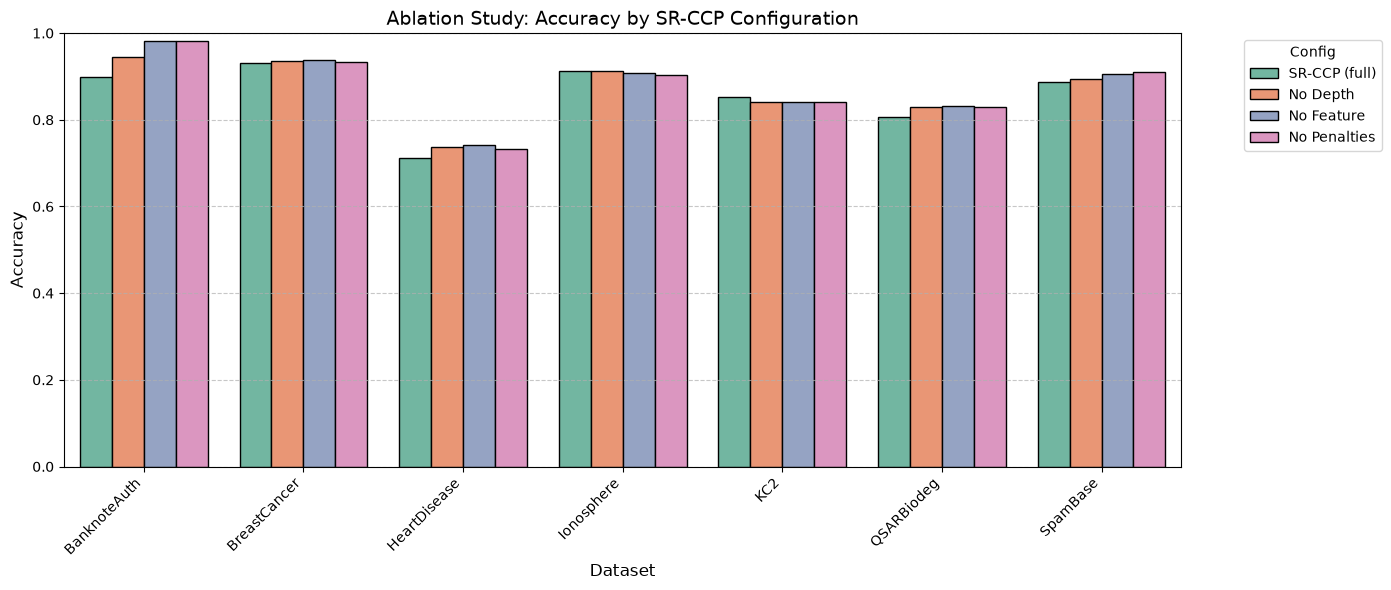

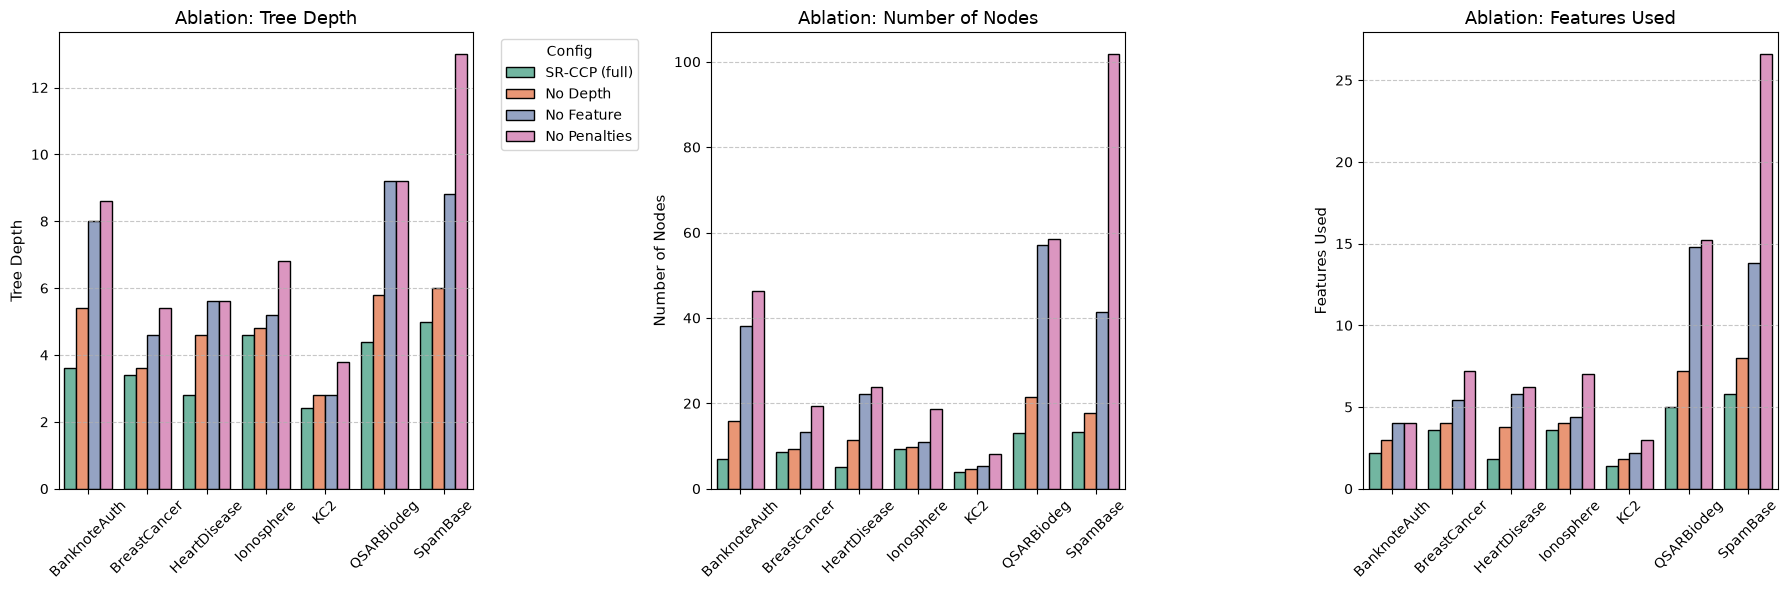


DELTA vs SR-CCP (full)

No Depth vs SR-CCP:
  Mean ΔAccuracy: 0.0134  Mean ΔFeatures: 1.2

No Feature vs SR-CCP:
  Mean ΔAccuracy: 0.0214  Mean ΔFeatures: 3.9

No Penalties vs SR-CCP:
  Mean ΔAccuracy: 0.0189  Mean ΔFeatures: 6.5


In [7]:
# ====================== ABLATION STUDY: SR-CCP COMPONENTS (Obs 14) ======================
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

configs = {
    'SR-CCP (full)':     {'depth_penalty': 'tune', 'feature_penalty_weight': 'tune'},
    'No Depth':          {'depth_penalty': 0,      'feature_penalty_weight': 'tune'},
    'No Feature':        {'depth_penalty': 'tune', 'feature_penalty_weight': 0},
    'No Penalties':      {'depth_penalty': 0,      'feature_penalty_weight': 0},
}

ablation_datasets = load_datasets()
ablation_results = []

for ds_name, X, y in ablation_datasets:
    print(f"\n{'='*60}")
    print(f"Dataset: {ds_name} (n={len(X)}, d={X.shape[1]})")
    print(f"{'='*60}")

    for cfg_name, cfg_params in configs.items():
        print(f"  {cfg_name}...")
        model_fns_abl = {
            cfg_name: lambda X_tr, y_tr, X_v, y_v, dp=cfg_params['depth_penalty'], fpw=cfg_params['feature_penalty_weight']: \
                train_ccp_ablation(X_tr, y_tr, X_v, y_v, depth_penalty=dp, feature_penalty_weight=fpw)
        }
        means, stds, _, _, _, _, _, _ = cross_validate_models(X, y, model_fns_abl, k=5)
        m = means[cfg_name]
        acc, f1, balanced_acc, depth, nodes, leaves, inference_time, inference_std, n_features_used, memory_kb = m
        ablation_results.append({
            'Dataset': ds_name, 'Config': cfg_name,
            'Accuracy': acc, 'F1': f1, 'Balanced_Acc': balanced_acc,
            'Depth': depth, 'Nodes': nodes, 'Leaves': leaves,
            'n_Features': n_features_used
        })

ablation_df = pd.DataFrame(ablation_results)

# --- Summary table ---
print("\n" + "="*80)
print("ABLATION SUMMARY (mean across datasets)")
print("="*80)
summary = ablation_df.groupby('Config')[['Accuracy', 'Depth', 'Nodes', 'Leaves', 'n_Features']].mean()
print(summary.round(4))

# --- Chart 1: Accuracy per config per dataset ---
plt.figure(figsize=(14, 6))
ax = sns.barplot(data=ablation_df, x='Dataset', y='Accuracy', hue='Config', palette='Set2', edgecolor='black')
plt.title('Ablation Study: Accuracy by SR-CCP Configuration', fontsize=14)
plt.ylabel('Accuracy', fontsize=12)
plt.xlabel('Dataset', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.ylim(0, 1)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='Config', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig('ablation_accuracy.png', dpi=150, bbox_inches='tight')
plt.show()

# --- Chart 2: Tree complexity (Depth, Nodes, n_Features) ---
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for ax, col, title in zip(axes, ['Depth', 'Nodes', 'n_Features'], ['Tree Depth', 'Number of Nodes', 'Features Used']):
    sns.barplot(data=ablation_df, x='Dataset', y=col, hue='Config', palette='Set2', edgecolor='black', ax=ax)
    ax.set_title(f'Ablation: {title}', fontsize=13)
    ax.set_ylabel(title, fontsize=11)
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=45)
    ax.grid(axis='y', linestyle='--', alpha=0.7)
    if ax != axes[0]:
        ax.get_legend().remove()
axes[0].legend(title='Config', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig('ablation_complexity.png', dpi=150, bbox_inches='tight')
plt.show()

# --- Delta from full SR-CCP ---
print("\n" + "="*80)
print("DELTA vs SR-CCP (full)")
print("="*80)
full = ablation_df[ablation_df['Config'] == 'SR-CCP (full)'].set_index('Dataset')
for cfg in ['No Depth', 'No Feature', 'No Penalties']:
    partial = ablation_df[ablation_df['Config'] == cfg].set_index('Dataset')
    delta_acc = partial['Accuracy'] - full['Accuracy']
    delta_feat = partial['n_Features'] - full['n_Features']
    print(f"\n{cfg} vs SR-CCP:")
    print(f"  Mean ΔAccuracy: {delta_acc.mean():.4f}  Mean ΔFeatures: {delta_feat.mean():.1f}")


In [8]:
"""
# ======================= ABLATION STUDY: n_trials (ALL DATASETS) ===========================
from functools import partial

def train_ccp_modified_n(X_train, y_train, X_val, y_val, n_trials=60):
    return train_ccp_modified_optimized(X_train, y_train, X_val, y_val,
                                         seed=42, n_trials=n_trials)

ablation_datasets = load_datasets()
trials_list = [5, 10, 15, 20, 30, 60]
all_ablation_results = []

for ds_name, X, y in ablation_datasets:
    print(f"\n{'='*60}")
    print(f"Dataset: {ds_name} (n={len(X)}, d={X.shape[1]})")
    print(f"{'='*60}")

    # Benchmark CCP estandar como referencia
    model_fns_ccp = {"CCP": train_ccp}
    t_ccp = time.perf_counter()
    cross_validate_models(X, y, model_fns_ccp, k=3)
    ccp_time = (time.perf_counter() - t_ccp) * 1000

    for n_t in trials_list:
        print(f"  n_trials={n_t}...")
        fn = partial(train_ccp_modified_n, n_trials=n_t)
        model_fns_abl = {
            "CCP": train_ccp,
            f"CCP_Mod({n_t})": fn,
        }
        t0 = time.perf_counter()
        means, stds, _, _, _, _, _, _ = cross_validate_models(X, y, model_fns_abl, k=3)
        total_ms = (time.perf_counter() - t0) * 1000

        m = means[f"CCP_Mod({n_t})"]
        m_ccp = means["CCP"]
        all_ablation_results.append({
            "dataset": ds_name,
            "n_trials": n_t,
            "accuracy": m[0],
            "f1": m[1],
            "balanced_acc": m[2],
            "total_time_ms": total_ms,
            "ccp_accuracy": m_ccp[0],
            "ccp_time_ms": ccp_time,
            "delta_acc": m[0] - m_ccp[0],
        })
        print(f"    Acc={m[0]:.4f}, CCP_Acc={m_ccp[0]:.4f}, dAcc={m[0]-m_ccp[0]:+.4f}, Time={total_ms:.0f}ms")

# =================== TABLA CONSOLIDADA ===================
print("\n" + "="*90)
print("ABLATION TABLE: n_trials vs Accuracy vs Time (ALL DATASETS)")
print("="*90)
print(f"{'Dataset':>16} {'n_trials':>8} {'Accuracy':>10} {'CCP_Acc':>10} {'dAcc':>8} {'Time(ms)':>10} {'CCP_Time':>10} {'Factor':>8}")
print("-"*90)
for r in all_ablation_results:
    factor = r["total_time_ms"] / r["ccp_time_ms"] if r["ccp_time_ms"] > 0 else 0
    print(f"{r['dataset']:>16} {r['n_trials']:>8} {r['accuracy']:>10.4f} {r['ccp_accuracy']:>10.4f} {r['delta_acc']:>+8.4f} {r['total_time_ms']:>10.0f} {r['ccp_time_ms']:>10.0f} {factor:>7.1f}x")

# =================== RESUMEN POR n_trials ===================
print("\n" + "="*70)
print("PROMEDIO POR n_trials (todos los datasets)")
print("="*70)
print(f"{'n_trials':>8} {'Avg_Acc':>10} {'Avg_dAcc':>10} {'Avg_Time':>10} {'Avg_Factor':>12}")
print("-"*55)
for n_t in trials_list:
    subset = [r for r in all_ablation_results if r["n_trials"] == n_t]
    avg_acc = np.mean([r["accuracy"] for r in subset])
    avg_dacc = np.mean([r["delta_acc"] for r in subset])
    avg_time = np.mean([r["total_time_ms"] for r in subset])
    avg_factor = np.mean([r["total_time_ms"] / r["ccp_time_ms"] for r in subset if r["ccp_time_ms"] > 0])
    print(f"{n_t:>8} {avg_acc:>10.4f} {avg_dacc:>+10.4f} {avg_time:>10.0f} {avg_factor:>11.1f}x")

# =================== GRAFICAS ===================
ablation_df = pd.DataFrame(all_ablation_results)

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Grafica 1: Accuracy por dataset y n_trials
for ds_name in ablation_df["dataset"].unique():
    subset = ablation_df[ablation_df["dataset"] == ds_name]
    axes[0].plot(subset["n_trials"], subset["accuracy"], 'o-', label=ds_name, linewidth=1.5, markersize=5)
axes[0].axvline(x=15, color='r', linestyle='--', alpha=0.7, label='n_trials=15')
axes[0].set_xlabel('n_trials')
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Accuracy por Dataset')
axes[0].legend(fontsize=7, loc='best')
axes[0].grid(True, alpha=0.3)

# Grafica 2: Delta Accuracy vs CCP
for ds_name in ablation_df["dataset"].unique():
    subset = ablation_df[ablation_df["dataset"] == ds_name]
    axes[1].plot(subset["n_trials"], subset["delta_acc"], 'o-', label=ds_name, linewidth=1.5, markersize=5)
axes[1].axhline(y=0, color='k', linestyle='-', alpha=0.3)
axes[1].axvline(x=15, color='r', linestyle='--', alpha=0.7, label='n_trials=15')
axes[1].set_xlabel('n_trials')
axes[1].set_ylabel('dAccuracy (CCP_Mod - CCP)')
axes[1].set_title('Delta Accuracy vs CCP Estandar')
axes[1].legend(fontsize=7, loc='best')
axes[1].grid(True, alpha=0.3)

# Grafica 3: Factor de tiempo vs CCP
for ds_name in ablation_df["dataset"].unique():
    subset = ablation_df[ablation_df["dataset"] == ds_name]
    factor = subset["total_time_ms"] / subset["ccp_time_ms"]
    axes[2].plot(subset["n_trials"], factor, 'o-', label=ds_name, linewidth=1.5, markersize=5)
axes[2].axvline(x=15, color='r', linestyle='--', alpha=0.7, label='n_trials=15')
axes[2].set_xlabel('n_trials')
axes[2].set_ylabel('Tiempo / Tiempo_CCP')
axes[2].set_title('Factor de Tiempo vs CCP')
axes[2].legend(fontsize=7, loc='best')
axes[2].grid(True, alpha=0.3)

plt.suptitle('Ablation Study: Efecto de n_trials en CCP_Modified (Todos los Datasets)', fontsize=14)
plt.tight_layout()
plt.show()
"""

'\n# ======================= ABLATION STUDY: n_trials (ALL DATASETS) ===========================\nfrom functools import partial\n\ndef train_ccp_modified_n(X_train, y_train, X_val, y_val, n_trials=60):\n    return train_ccp_modified_optimized(X_train, y_train, X_val, y_val,\n                                         seed=42, n_trials=n_trials)\n\nablation_datasets = load_datasets()\ntrials_list = [5, 10, 15, 20, 30, 60]\nall_ablation_results = []\n\nfor ds_name, X, y in ablation_datasets:\n    print(f"\n{\'=\'*60}")\n    print(f"Dataset: {ds_name} (n={len(X)}, d={X.shape[1]})")\n    print(f"{\'=\'*60}")\n\n    # Benchmark CCP estandar como referencia\n    model_fns_ccp = {"CCP": train_ccp}\n    t_ccp = time.perf_counter()\n    cross_validate_models(X, y, model_fns_ccp, k=3)\n    ccp_time = (time.perf_counter() - t_ccp) * 1000\n\n    for n_t in trials_list:\n        print(f"  n_trials={n_t}...")\n        fn = partial(train_ccp_modified_n, n_trials=n_t)\n        model_fns_abl = {\n       

         Dataset        Method  Accuracy  F1_Score  Balanced_Accuracy  Depth  \
0   BanknoteAuth          Base  0.981046  0.980822           0.981132    8.6   
1   BanknoteAuth           CCP  0.981776  0.981564           0.981952    8.6   
2   BanknoteAuth  CCP_Modified  0.916170  0.914738           0.912895    4.2   
3   BanknoteAuth           REP  0.964279  0.963761           0.963102    6.6   
4   BanknoteAuth           MEP  0.964279  0.963761           0.963102    6.6   
5   BanknoteAuth  DepthPruning  0.973033  0.972702           0.972789    6.0   
6   BreastCancer          Base  0.920928  0.914839           0.913092    7.4   
7   BreastCancer           CCP  0.933209  0.928497           0.927645    5.4   
8   BreastCancer  CCP_Modified  0.935010  0.930470           0.930081    3.6   
9   BreastCancer           REP  0.929747  0.924993           0.924883    4.4   
10  BreastCancer           MEP  0.931501  0.926798           0.926272    4.4   
11  BreastCancer  DepthPruning  0.927977

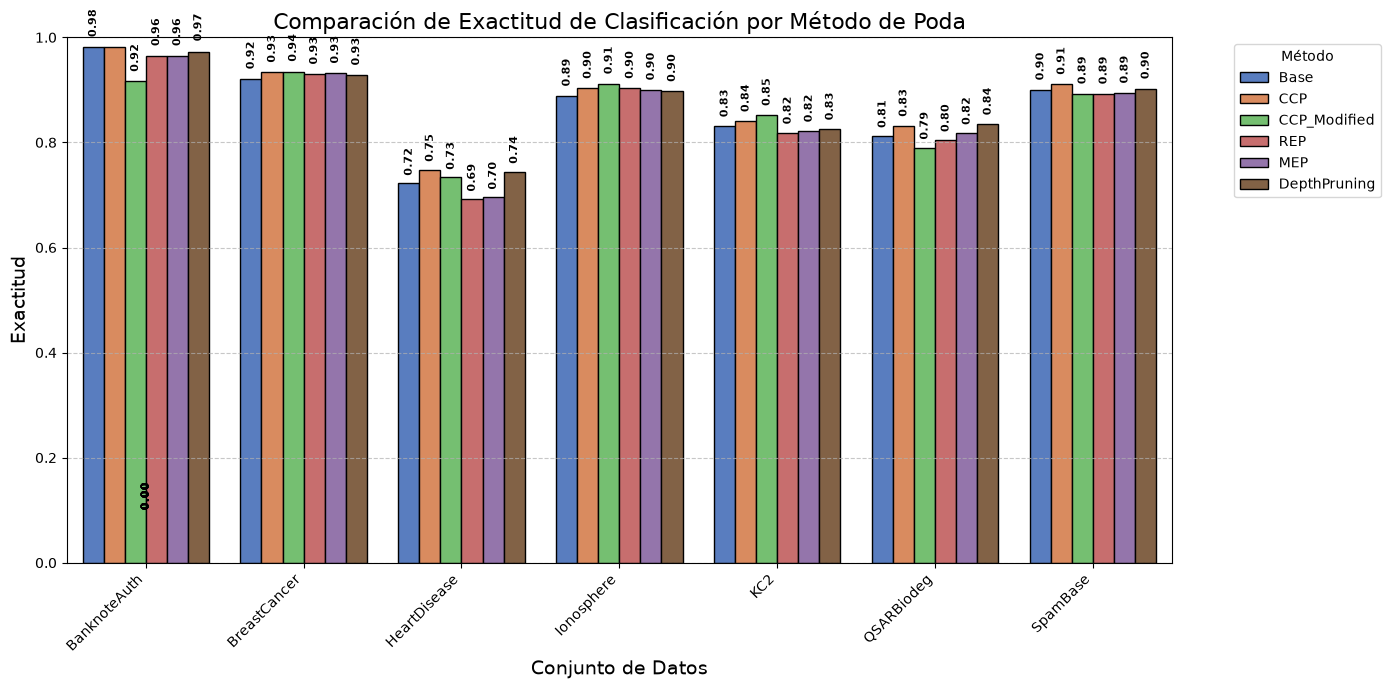

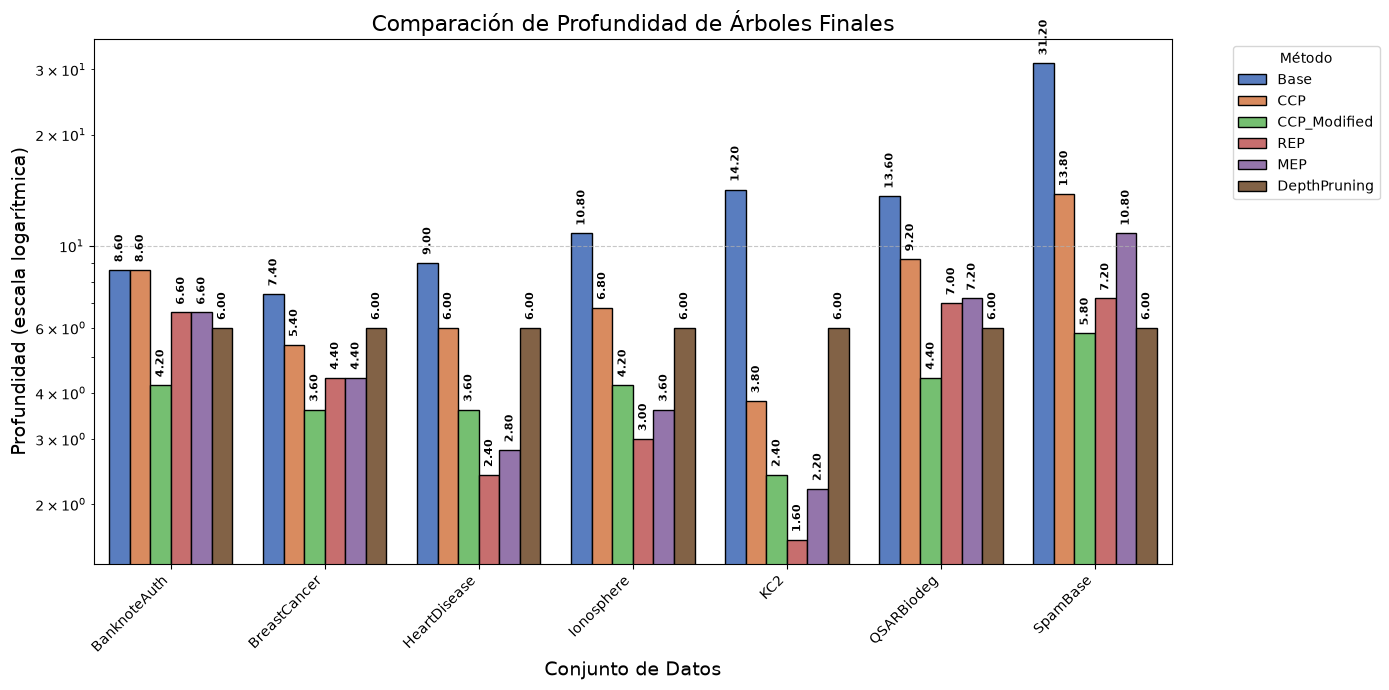

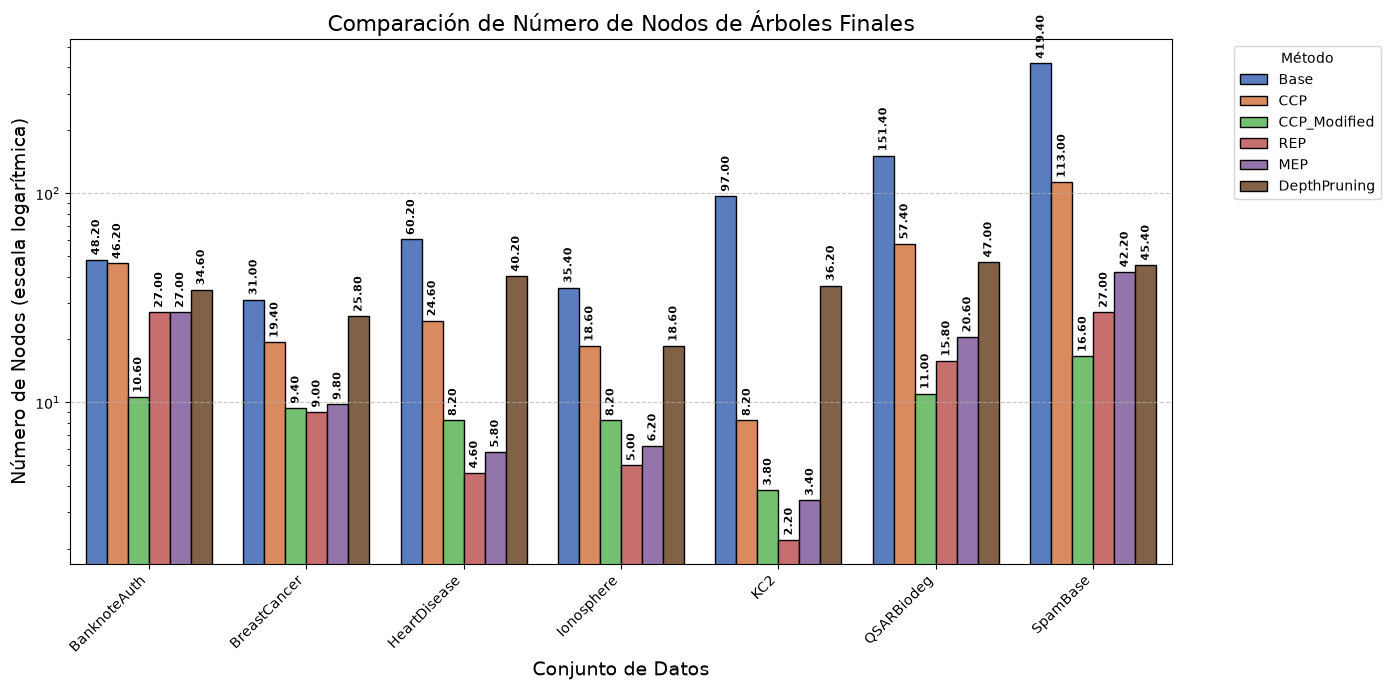

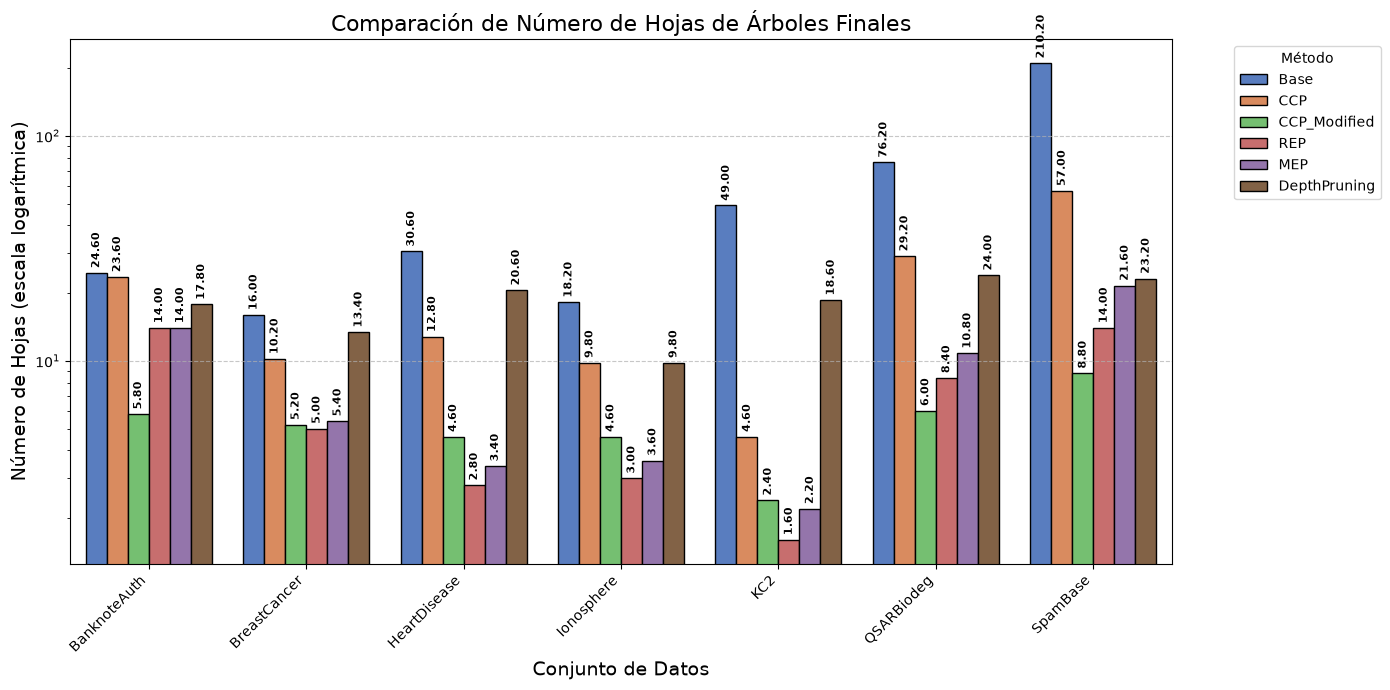

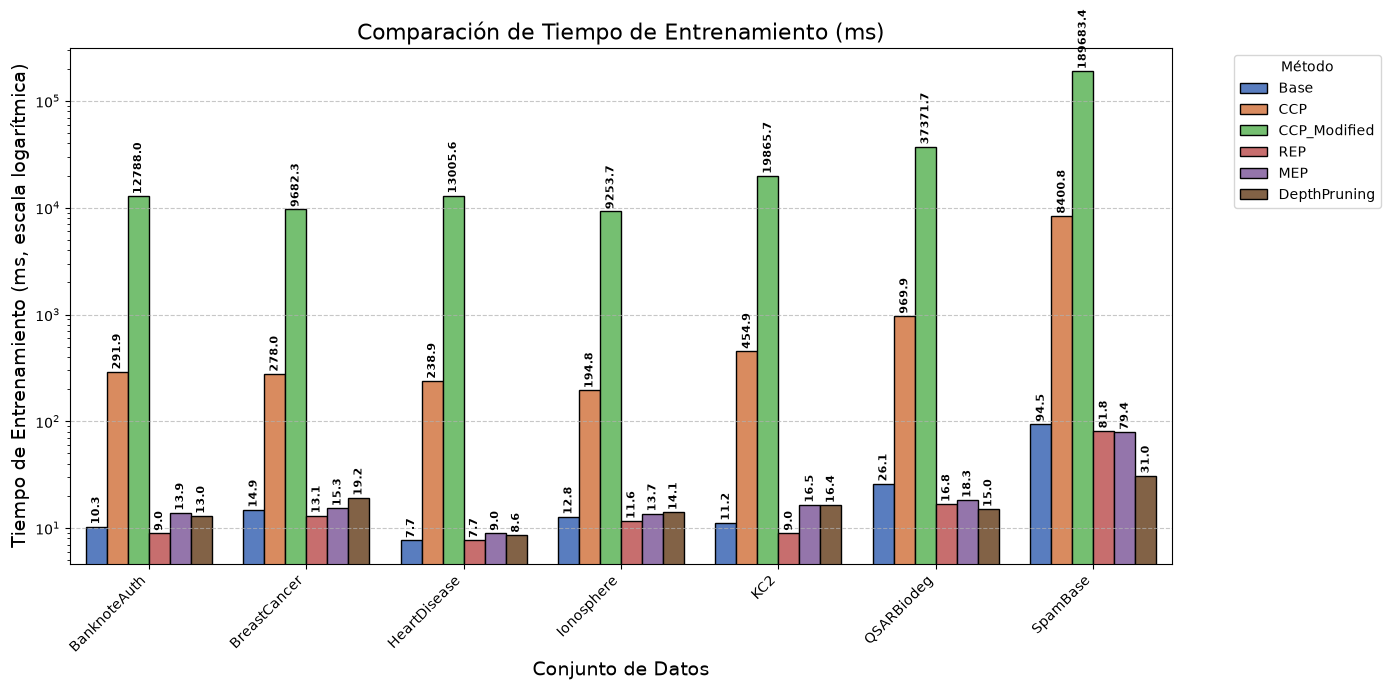

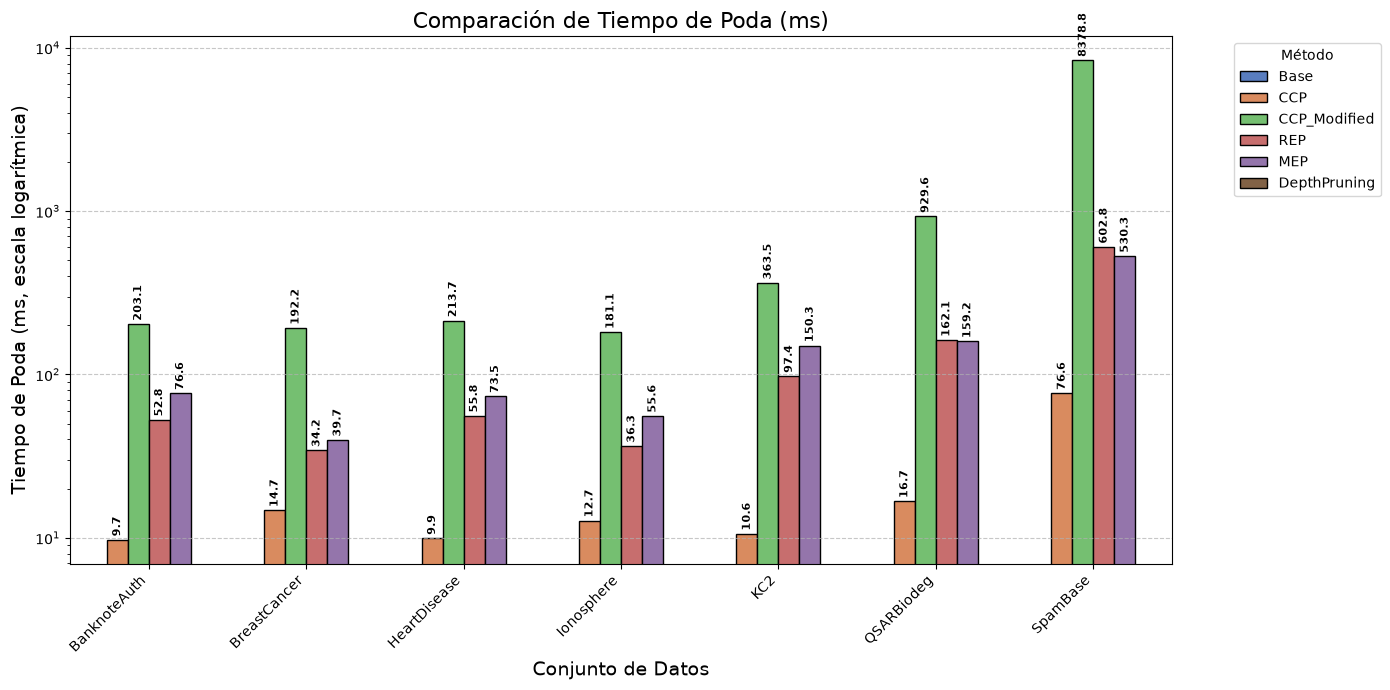

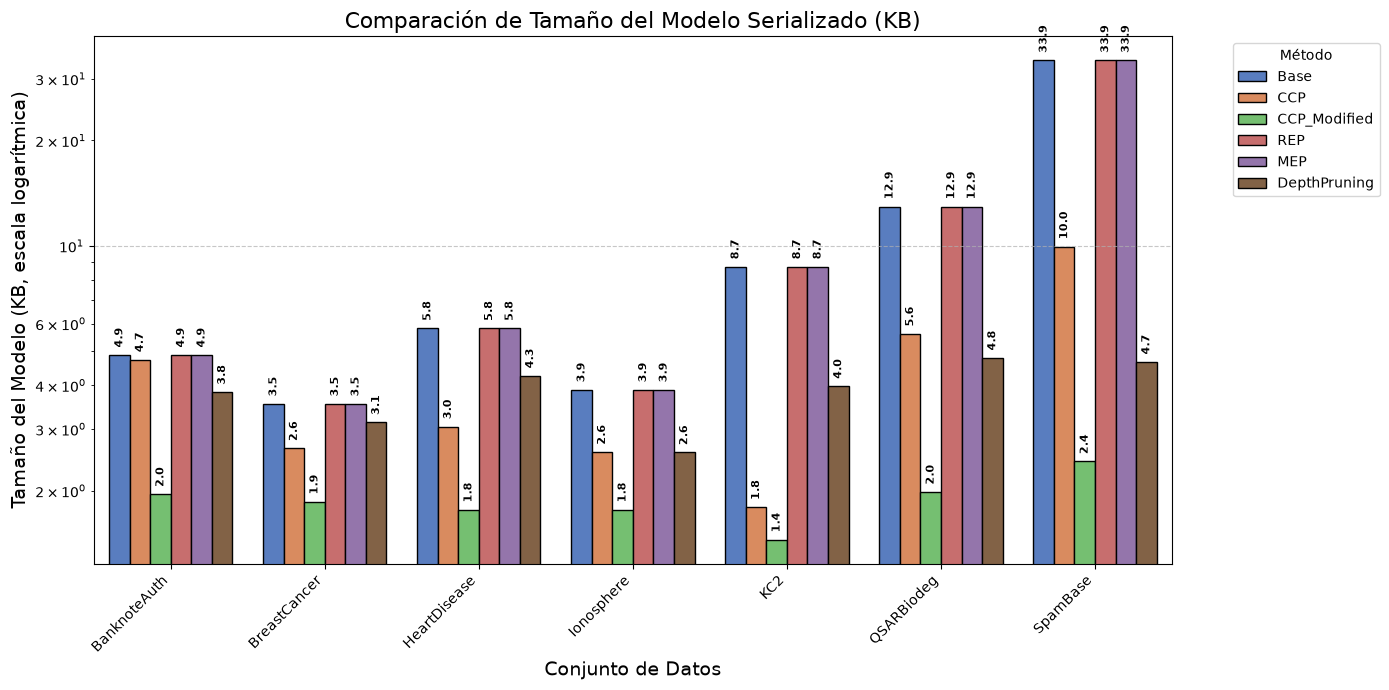

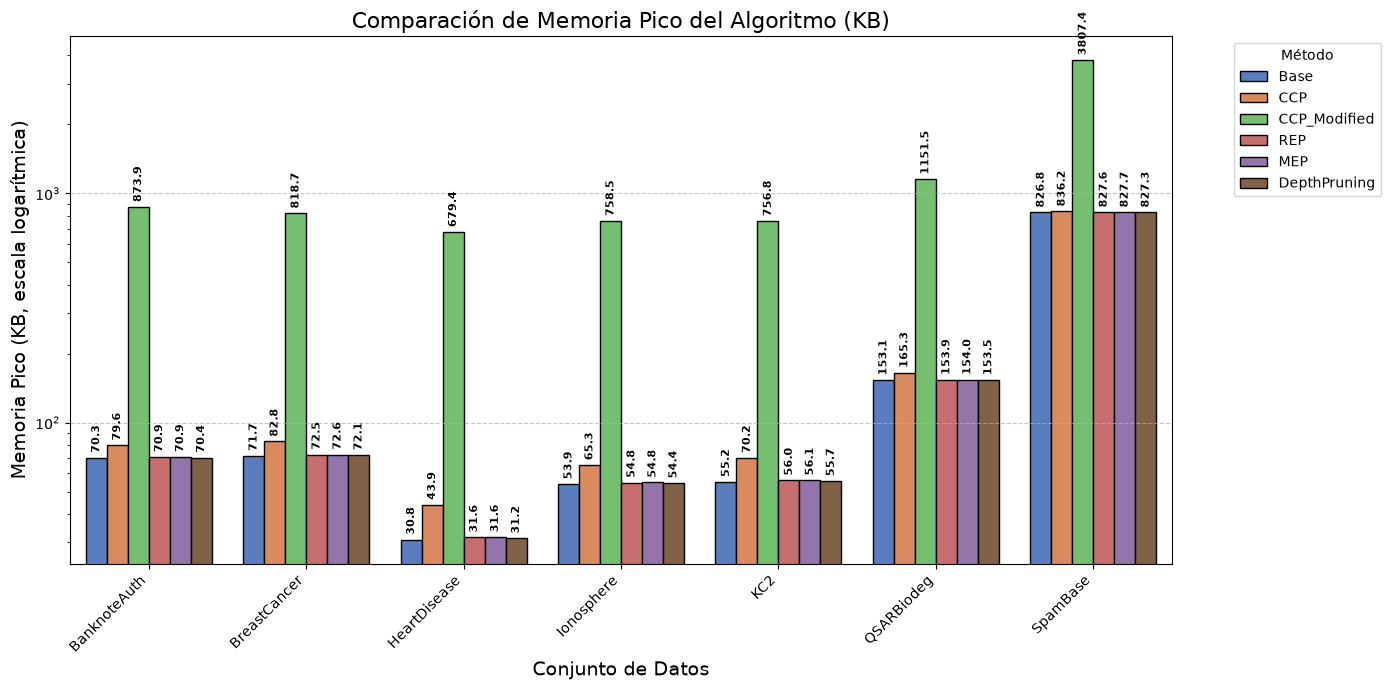

In [9]:
# ======================= RESULTADOS ===========================
results_df = pd.DataFrame(results, columns=[
    "Dataset", "Method", "Accuracy", "F1_Score", "Balanced_Accuracy",
    "Depth", "Nodes", "Leaves", "Inference_Time_ms", "Inference_Time_Std_ms", "n_Features",
    "Train_Time_ms", "Prune_Time_ms", "Memory_KB", "Peak_Memory_KB"
])
print(results_df)

# ========== RESULTADOS ADICIONALES ==========
metrics_df = results_df[["Dataset", "Method", "Accuracy", "F1_Score", "Balanced_Accuracy", "Inference_Time_ms", "Inference_Time_Std_ms", "n_Features", "Train_Time_ms", "Prune_Time_ms", "Memory_KB", "Peak_Memory_KB"]]
accuracy_df = results_df[["Dataset", "Method", "Accuracy"]].rename(columns={"Accuracy": "Test Accuracy"})
details_df = results_df[["Dataset", "Method", "Depth", "Nodes", "Leaves"]]

print("\nMetricas de Prueba por Método:")
print(metrics_df.pivot(index="Dataset", columns="Method"))

print("\nDetalles de Árboles:")
print(details_df)

#========================== ANOVA ===================================

anova_result_acc = f_oneway(*[group['Accuracy'].values for name, group in metrics_df.groupby('Method')])
anova_result_f1 = f_oneway(*[group['F1_Score'].values for name, group in metrics_df.groupby('Method')])
anova_result_bal = f_oneway(*[group['Balanced_Accuracy'].values for name, group in metrics_df.groupby('Method')])

anova_result_depth = f_oneway(*[group['Depth'].values for name, group in details_df.groupby('Method')])
anova_result_nodes = f_oneway(*[group['Nodes'].values for name, group in details_df.groupby('Method')])
anova_result_leav = f_oneway(*[group['Leaves'].values for name, group in details_df.groupby('Method')])

anova_featu_nodes = f_oneway(*[group['n_Features'].values for name, group in metrics_df.groupby('Method')])
print(f'ANOVA Accuracy:     F={anova_result_acc.statistic:.2f}, p={anova_result_acc.pvalue:.4f}')
print(f'ANOVA F1:           F={anova_result_f1.statistic:.2f}, p={anova_result_f1.pvalue:.4f}')
print(f'ANOVA Balanced Acc: F={anova_result_bal.statistic:.2f}, p={anova_result_bal.pvalue:.4f}')
print(f'ANOVA Depth:        F={anova_result_depth.statistic:.2f}, p={anova_result_depth.pvalue:.4f}')
print(f'ANOVA Nodes:        F={anova_result_nodes.statistic:.2f}, p={anova_result_nodes.pvalue:.4f}')
print(f'ANOVA Leaves:       F={anova_result_leav.statistic:.2f}, p={anova_result_leav.pvalue:.4f}')
print(f'ANOVA Features:     F={anova_featu_nodes.statistic:.2f}, p={anova_featu_nodes.pvalue:.4f}')

# ========================== CSV FINAL UNIFICADO CON Δacc ==========================

# Obtener accuracy base por dataset
base_accuracies = results_df[results_df["Method"] == "Base"][["Dataset", "Accuracy"]].set_index("Dataset")

# Añadir columna Δacc
results_df["△acc"] = results_df.apply(
    lambda row: row["Accuracy"] - base_accuracies.loc[row["Dataset"], "Accuracy"]
    if row["Method"] != "Base" else 0.0,
    axis=1
)

# Reordenar y renombrar columnas
final_df = results_df[["Dataset", "Method", "Accuracy", "△acc", "F1_Score", "Balanced_Accuracy", "Leaves", "Nodes", "Depth", "Inference_Time_ms", "Inference_Time_Std_ms", "n_Features", "Train_Time_ms", "Prune_Time_ms", "Memory_KB", "Peak_Memory_KB"]]

# Guardar CSV final
final_df.to_csv("FINAL_RESULTADOS.csv", index=False)

# Mostrar resumen final
print("\nCSV Final Consolidado:")
print(final_df)


# Descargar en Colab si aplica
try:
    from google.colab import files
    files.download("FINAL_RESULTADOS.csv")
except:
    print("Descarga automática no disponible (no estás en Colab).")


#==============GRAFICAS INTERPRETABLES==================


# Función para anotar las barras
def annotate_bars(ax, fmt="{:.2f}"):
    """Añade etiquetas numéricas encima de cada barra, separadas adecuadamente."""
    for p in ax.patches:
        height = p.get_height()
        offset = height * 0.020 if height > 0 else 0.1
        ax.annotate(fmt.format(height),
                    (p.get_x() + p.get_width() / 2., height + offset),
                    ha='center', va='bottom',
                    fontsize=8, fontweight='bold', color='black', rotation=90)

# === Gráfica 1: Exactitud por Método ===
plt.figure(figsize=(14, 7))
ax = sns.barplot(data=accuracy_df, x="Dataset", y="Test Accuracy", hue="Method", palette="muted", edgecolor="black")
plt.title("Comparación de Exactitud de Clasificación por Método de Poda", fontsize=16)
plt.ylabel("Exactitud", fontsize=14)
plt.xlabel("Conjunto de Datos", fontsize=14)
plt.xticks(rotation=45, ha="right")
plt.ylim(0, 1)
plt.grid(axis="y", linestyle='--', alpha=0.7)
plt.legend(title="Método", bbox_to_anchor=(1.05, 1), loc='upper left')
annotate_bars(ax, fmt="{:.2f}")
plt.tight_layout()
plt.show()

#CARACTERÍSTICAS

# Función para anotar las barras correctamente, incluso las de valor 0
def annotate_bars(ax, fmt="{:.2f}"):
    """Añade etiquetas numéricas encima de cada barra, manejando valores cero correctamente."""
    for p in ax.patches:
        height = p.get_height()
        if height == 0:
            ax.annotate("0",
                        (p.get_x() + p.get_width() / 2., 0.2),
                        ha='center', va='bottom',
                        fontsize=8, fontweight='bold', color='black', rotation=90)
        else:
            offset = height * 0.05
            ax.annotate(fmt.format(height),
                        (p.get_x() + p.get_width() / 2., height + offset),
                        ha='center', va='bottom',
                        fontsize=8, fontweight='bold', color='black', rotation=90)

# === Gráfica 2: Profundidad de Árboles (con escala logarítmica) ===
plt.figure(figsize=(14, 7))
ax = sns.barplot(data=details_df, x="Dataset", y="Depth", hue="Method", palette="muted", edgecolor="black")
plt.yscale('log')
plt.title("Comparación de Profundidad de Árboles Finales", fontsize=16)
plt.ylabel("Profundidad (escala logarítmica)", fontsize=14)
plt.xlabel("Conjunto de Datos", fontsize=14)
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", linestyle='--', alpha=0.7)
plt.legend(title="Método", bbox_to_anchor=(1.05, 1), loc='upper left')
annotate_bars(ax, fmt="{:.2f}")
plt.tight_layout()
plt.show()

# === Gráfica 3: Cantidad de Nodos (con escala logarítmica) ===
plt.figure(figsize=(14, 7))
ax = sns.barplot(data=details_df, x="Dataset", y="Nodes", hue="Method", palette="muted", edgecolor="black")
plt.yscale('log')
plt.title("Comparación de Número de Nodos de Árboles Finales", fontsize=16)
plt.ylabel("Número de Nodos (escala logarítmica)", fontsize=14)
plt.xlabel("Conjunto de Datos", fontsize=14)
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", linestyle='--', alpha=0.7)
plt.legend(title="Método", bbox_to_anchor=(1.05, 1), loc='upper left')
annotate_bars(ax, fmt="{:.2f}")
plt.tight_layout()
plt.show()

# === Gráfica 4: Cantidad de Hojas (con escala logarítmica) ===
plt.figure(figsize=(14, 7))
ax = sns.barplot(data=details_df, x="Dataset", y="Leaves", hue="Method", palette="muted", edgecolor="black")
plt.yscale('log')
plt.title("Comparación de Número de Hojas de Árboles Finales", fontsize=16)
plt.ylabel("Número de Hojas (escala logarítmica)", fontsize=14)
plt.xlabel("Conjunto de Datos", fontsize=14)
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", linestyle='--', alpha=0.7)
plt.legend(title="Método", bbox_to_anchor=(1.05, 1), loc='upper left')
annotate_bars(ax, fmt="{:.2f}")
plt.tight_layout()
plt.show()

# === Gráfica 5: Tiempo de Entrenamiento (escala log) ===
train_time_df = results_df[["Dataset", "Method", "Train_Time_ms"]]
plt.figure(figsize=(14, 7))
ax = sns.barplot(data=train_time_df, x="Dataset", y="Train_Time_ms", hue="Method", palette="muted", edgecolor="black")
plt.yscale('log')
plt.title("Comparación de Tiempo de Entrenamiento (ms)", fontsize=16)
plt.ylabel("Tiempo de Entrenamiento (ms, escala logarítmica)", fontsize=14)
plt.xlabel("Conjunto de Datos", fontsize=14)
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", linestyle='--', alpha=0.7)
plt.legend(title="Método", bbox_to_anchor=(1.05, 1), loc='upper left')
annotate_bars(ax, fmt="{:.1f}")
plt.tight_layout()
plt.show()

# === Gráfica 6: Tiempo de Poda (escala log) ===
prune_time_df = results_df[["Dataset", "Method", "Prune_Time_ms"]]
plt.figure(figsize=(14, 7))
ax = sns.barplot(data=prune_time_df, x="Dataset", y="Prune_Time_ms", hue="Method", palette="muted", edgecolor="black")
plt.yscale('log')
plt.title("Comparación de Tiempo de Poda (ms)", fontsize=16)
plt.ylabel("Tiempo de Poda (ms, escala logarítmica)", fontsize=14)
plt.xlabel("Conjunto de Datos", fontsize=14)
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", linestyle='--', alpha=0.7)
plt.legend(title="Método", bbox_to_anchor=(1.05, 1), loc='upper left')
annotate_bars(ax, fmt="{:.1f}")
plt.tight_layout()
plt.show()

# === Gráfica 7: Memoria del Modelo Serializado (escala log) ===
memory_df = results_df[["Dataset", "Method", "Memory_KB"]]
plt.figure(figsize=(14, 7))
ax = sns.barplot(data=memory_df, x="Dataset", y="Memory_KB", hue="Method", palette="muted", edgecolor="black")
plt.yscale('log')
plt.title("Comparación de Tamaño del Modelo Serializado (KB)", fontsize=16)
plt.ylabel("Tamaño del Modelo (KB, escala logarítmica)", fontsize=14)
plt.xlabel("Conjunto de Datos", fontsize=14)
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", linestyle='--', alpha=0.7)
plt.legend(title="Método", bbox_to_anchor=(1.05, 1), loc='upper left')
annotate_bars(ax, fmt="{:.1f}")
plt.tight_layout()
plt.show()

# === Gráfica 8: Memoria Pico del Algoritmo (escala log) ===
peak_memory_df = results_df[["Dataset", "Method", "Peak_Memory_KB"]]
plt.figure(figsize=(14, 7))
ax = sns.barplot(data=peak_memory_df, x="Dataset", y="Peak_Memory_KB", hue="Method", palette="muted", edgecolor="black")
plt.yscale('log')
plt.title("Comparación de Memoria Pico del Algoritmo (KB)", fontsize=16)
plt.ylabel("Memoria Pico (KB, escala logarítmica)", fontsize=14)
plt.xlabel("Conjunto de Datos", fontsize=14)
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", linestyle='--', alpha=0.7)
plt.legend(title="Método", bbox_to_anchor=(1.05, 1), loc='upper left')
annotate_bars(ax, fmt="{:.1f}")
plt.tight_layout()
plt.show()


Methods: ['Base', 'CCP', 'DBP', 'MEP', 'REP', 'SR-CCP']
Datasets: 7
Method          Base     CCP     DBP     MEP     REP  SR-CCP
Dataset                                                     
BanknoteAuth  0.9832  0.9869  0.9708  0.9876  0.9847  0.9874
BreastCancer  0.9104  0.9315  0.9280  0.9332  0.9314  0.9438
HeartDisease  0.7259  0.7852  0.7370  0.7741  0.7556  0.7963
Ionosphere    0.8974  0.9117  0.8974  0.9202  0.9117  0.9165
KC2           0.8181  0.8602  0.8161  0.8372  0.8372  0.8506
QSARBiodeg    0.8171  0.8483  0.8313  0.8493  0.8313  0.8502
SpamBase      0.9063  0.9215  0.9065  0.9148  0.9089  0.9178

FRIEDMAN TEST
Friedman chi2 = 29.57, p = 0.0000
-> Methods differ significantly across datasets (p < 0.05)

Average Ranks (lower = better):
  SR-CCP              : 1.57
  MEP                 : 2.21
  CCP                 : 2.36
  REP                 : 3.93
  DBP                 : 5.36
  Base                : 5.57

Nemenyi Critical Difference (CD) = 5.120 (alpha=0.05, k=6, N=7)

Pa

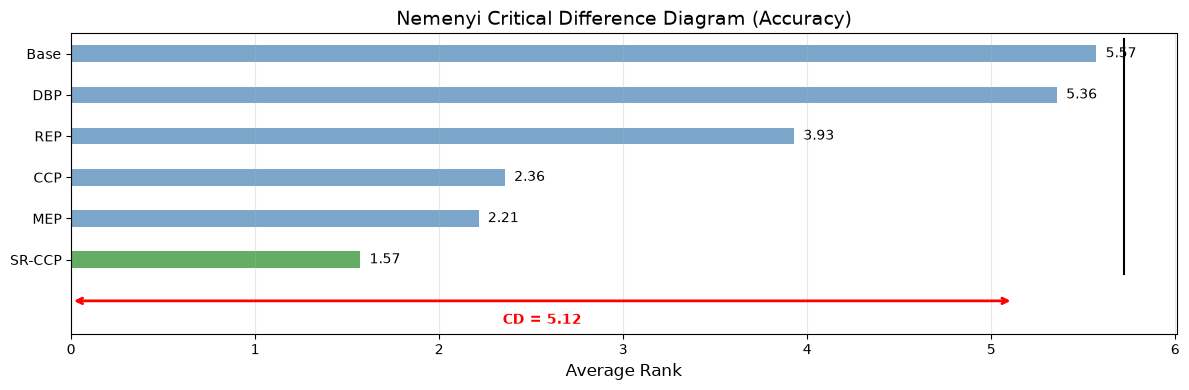

CD diagram saved to nemenyi_cd_diagram.png

WILCOXON SIGNED-RANK TEST (SR-CCP vs each method)

Wilcoxon signed-rank test (two-sided, alpha=0.05):
Holm correction for 5 comparisons
Method                 W-stat    p-value     Holm p  Significant
-----------------------------------------------------------------
Base                     0.00     0.0156     0.0781           no
DBP                      0.00     0.0156     0.0625           no
REP                      0.00     0.0156     0.0469      YES ***
MEP                      5.00     0.1562     0.3125           no
CCP                      8.00     0.3750     0.3750           no

SR-CCP is significantly different from: ['REP']

PAIRED T-TEST (SR-CCP vs each method)

Paired t-test (two-sided, alpha=0.05):
Holm correction for 5 comparisons
Method                 t-stat    p-value     Holm p  Significant
-----------------------------------------------------------------
DBP                      3.97     0.0074     0.0370      YES ***
Base  

In [10]:
# ====================== FRIEDMAN + NEMENYI TESTS ======================
from scipy.stats import friedmanchisquare, wilcoxon, ttest_rel
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --- 1. Load data from mean_accuracy.csv ---
acc_df = pd.read_csv('RESULTADOS_PAPER.csv')
acc_pivot = acc_df.pivot(index='Dataset', columns='Method', values='Accuracy')
methods = list(acc_pivot.columns)
k = len(methods)
N = len(acc_pivot)

print(f'Methods: {methods}')
print(f'Datasets: {N}')
print(acc_pivot.round(4))

# --- 2. Friedman test (omnibus) ---
print('\n' + '='*60)
print('FRIEDMAN TEST')
print('='*60)
stat, pvalue = friedmanchisquare(*[acc_pivot[m].values for m in methods])
print(f'Friedman chi2 = {stat:.2f}, p = {pvalue:.4f}')
if pvalue < 0.05:
    print('-> Methods differ significantly across datasets (p < 0.05)')
else:
    print('-> No significant difference found between methods (p >= 0.05)')

# --- 3. Compute average ranks ---
rank_matrix = acc_pivot.rank(axis=1, ascending=False, method='average')
avg_ranks = rank_matrix.mean(axis=0).sort_values()
print('\nAverage Ranks (lower = better):')
for method, rank in avg_ranks.items():
    print(f'  {method:20s}: {rank:.2f}')

# --- 4. Nemenyi post-hoc: Critical Difference ---
q_values = {
    (2,2):18.0,(2,3):6.16,(2,4):4.95,(2,5):4.60,(2,6):4.34,(2,7):4.16,(2,8):4.04,
    (2,9):3.95,(2,10):3.88,(2,15):3.65,(2,20):3.53,(2,30):3.40,
    (3,3):6.34,(3,4):5.24,(3,5):4.91,(3,6):4.68,(3,7):4.53,(3,8):4.41,(3,9):4.33,(3,10):4.26,
    (4,4):5.50,(4,5):5.16,(4,6):4.95,(4,7):4.79,(4,8):4.67,(4,9):4.59,(4,10):4.52,
    (5,5):5.33,(5,6):5.12,(5,7):4.99,(5,8):4.89,(5,9):4.81,(5,10):4.74,
    (6,6):5.24,(6,7):5.12,(6,8):5.02,(6,9):4.95,(6,10):4.88,
}
q_alpha = q_values.get((k, N), 4.039)
CD = q_alpha * np.sqrt(k * (k + 1) / (6 * N))
print(f'\nNemenyi Critical Difference (CD) = {CD:.3f} (alpha=0.05, k={k}, N={N})')

# --- 5. Pairwise rank differences ---
print('\nPairwise rank differences (pairs exceeding CD are significant):')
print(f'{"Pair":<40s} {"Rank Diff":>10s} {"Significant":>12s}')
print('-' * 65)
for i, m1 in enumerate(methods):
    for m2 in methods[i+1:]:
        diff = abs(avg_ranks[m1] - avg_ranks[m2])
        sig = 'YES ***' if diff >= CD else 'no'
        print(f'{m1 + " vs " + m2:<40s} {diff:>10.3f} {sig:>12s}')

# --- 6. CD Diagram ---
fig, ax = plt.subplots(figsize=(12, 4))
sorted_ranks = avg_ranks.sort_values()

for i, (method, rank) in enumerate(sorted_ranks.items()):
    color = 'forestgreen' if method == 'SR-CCP' else 'steelblue'
    ax.barh(i, rank, height=0.4, color=color, alpha=0.7)
    ax.text(rank + 0.05, i, f'{rank:.2f}', va='center', fontsize=10)

y_cd = -1
ax.annotate('', xy=(0, y_cd), xytext=(CD, y_cd),
            arrowprops=dict(arrowstyle='<->', color='red', lw=2))
ax.text(CD / 2, y_cd - 0.3, f'CD = {CD:.2f}', ha='center', va='top', color='red', fontweight='bold')

ax.set_yticks(range(len(sorted_ranks)))
ax.set_yticklabels(sorted_ranks.index, fontsize=10)
ax.set_xlabel('Average Rank', fontsize=12)
ax.set_title('Nemenyi Critical Difference Diagram (Accuracy)', fontsize=14)
ax.set_ylim(-1.8, len(sorted_ranks) - 0.5)
ax.grid(axis='x', alpha=0.3)

groups = []
current_group = [sorted_ranks.index[0]]
for i in range(1, len(sorted_ranks)):
    if sorted_ranks.iloc[i] - sorted_ranks.iloc[0] < CD:
        current_group.append(sorted_ranks.index[i])
    else:
        groups.append(current_group)
        current_group = [sorted_ranks.index[i]]
groups.append(current_group)

for group in groups:
    indices = [list(sorted_ranks.index).index(m) for m in group]
    y_top = max(indices) + 0.35
    y_bot = min(indices) - 0.35
    x_pos = max(sorted_ranks[m] for m in group) + 0.15
    ax.plot([x_pos, x_pos], [y_bot, y_top], color='black', lw=1.5)

plt.tight_layout()
plt.savefig('nemenyi_cd_diagram.png', dpi=150, bbox_inches='tight')
plt.show()
print('CD diagram saved to nemenyi_cd_diagram.png')

# --- 7. Wilcoxon signed-rank test (SR-CCP vs each method, Holm correction) ---
alpha = 0.05
target = 'SR-CCP'
other_methods = [m for m in methods if m != target]
n_comparisons = len(other_methods)

print('\n' + '='*60)
print('WILCOXON SIGNED-RANK TEST (SR-CCP vs each method)')
print('='*60)

wilcoxon_results = []
for m in other_methods:
    scores_a = acc_pivot[target].values
    scores_b = acc_pivot[m].values
    diff = scores_a - scores_b
    if np.all(diff == 0):
        w_stat, p_val = np.nan, np.nan
    else:
        w_stat, p_val = wilcoxon(scores_a, scores_b)
    wilcoxon_results.append((m, w_stat, p_val))

wilcoxon_results.sort(key=lambda x: x[2] if not np.isnan(x[2]) else 1.0)

print(f'\nWilcoxon signed-rank test (two-sided, alpha={alpha}):')
print(f'Holm correction for {n_comparisons} comparisons')
print(f'{"Method":<20s} {"W-stat":>8s} {"p-value":>10s} {"Holm p":>10s} {"Significant":>12s}')
print('-' * 65)
for rank_idx, (m, w_stat, p_val) in enumerate(wilcoxon_results):
    holm_alpha = alpha / (n_comparisons - rank_idx)
    if np.isnan(p_val):
        sig = 'N/A (all equal)'
        holm_p = np.nan
    else:
        holm_p = min(p_val * (n_comparisons - rank_idx), 1.0)
        sig = 'YES ***' if p_val < holm_alpha else 'no'
    w_str = f'{w_stat:.2f}' if not np.isnan(w_stat) else 'N/A'
    p_str = f'{p_val:.4f}' if not np.isnan(p_val) else 'N/A'
    holm_str = f'{holm_p:.4f}' if not np.isnan(holm_p) else 'N/A'
    print(f'{m:<20s} {w_str:>8s} {p_str:>10s} {holm_str:>10s} {sig:>12s}')

significant_methods = [m for m, w, p in wilcoxon_results if not np.isnan(p) and p < alpha / (n_comparisons - wilcoxon_results.index((m, w, p)))]
if significant_methods:
    print(f'\nSR-CCP is significantly different from: {significant_methods}')
else:
    print(f'\nSR-CCP is NOT significantly different from any method (at alpha={alpha} with Holm correction)')

# --- 8. Paired t-test (SR-CCP vs each method, Holm correction) ---
print('\n' + '='*60)
print('PAIRED T-TEST (SR-CCP vs each method)')
print('='*60)

ttest_results = []
for m in other_methods:
    scores_a = acc_pivot[target].values
    scores_b = acc_pivot[m].values
    t_stat, p_val = ttest_rel(scores_a, scores_b)
    ttest_results.append((m, t_stat, p_val))

ttest_results.sort(key=lambda x: x[2])

print(f'\nPaired t-test (two-sided, alpha={alpha}):')
print(f'Holm correction for {n_comparisons} comparisons')
print(f'{"Method":<20s} {"t-stat":>8s} {"p-value":>10s} {"Holm p":>10s} {"Significant":>12s}')
print('-' * 65)
ttest_sig_methods = []
for rank_idx, (m, t_stat, p_val) in enumerate(ttest_results):
    holm_alpha = alpha / (n_comparisons - rank_idx)
    holm_p = min(p_val * (n_comparisons - rank_idx), 1.0)
    sig = 'YES ***' if p_val < holm_alpha else 'no'
    if p_val < holm_alpha:
        ttest_sig_methods.append(m)
    print(f'{m:<20s} {t_stat:>8.2f} {p_val:>10.4f} {holm_p:>10.4f} {sig:>12s}')

if ttest_sig_methods:
    print(f'\nSR-CCP is significantly different from: {ttest_sig_methods}')
else:
    print(f'\nSR-CCP is NOT significantly different from any method (at alpha={alpha} with Holm correction)')


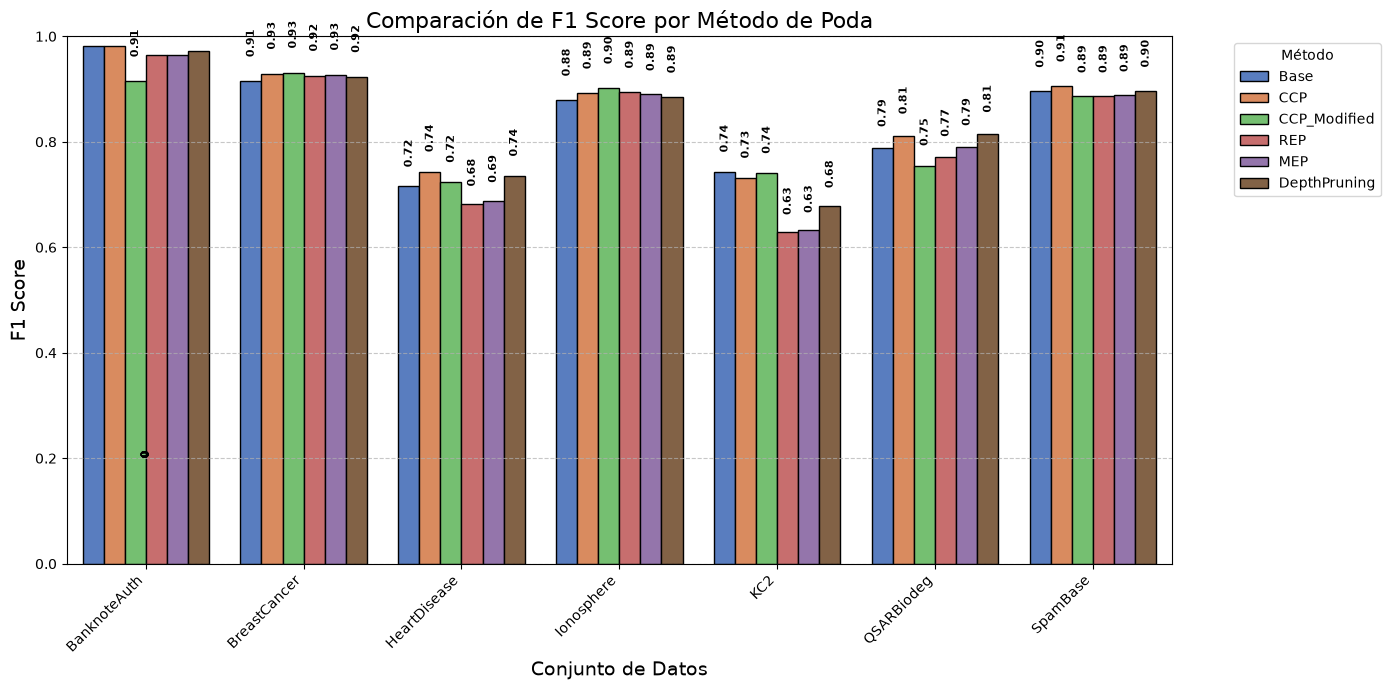

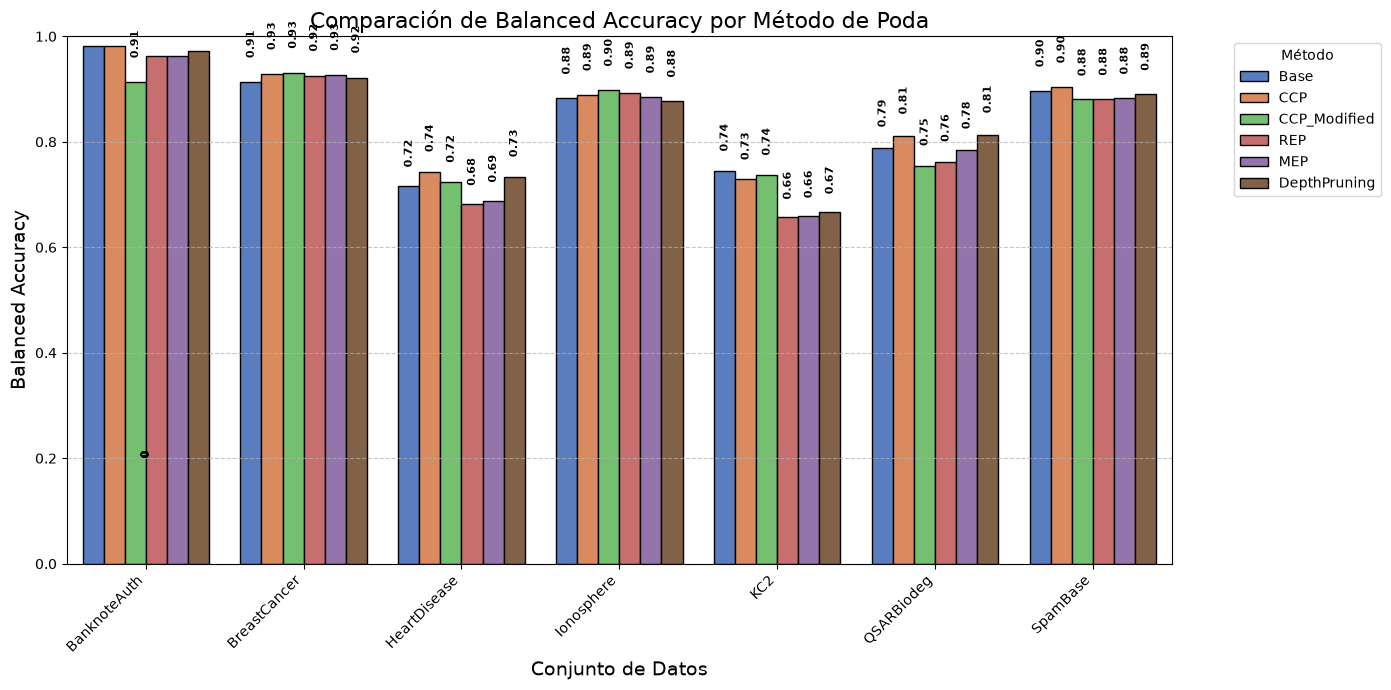

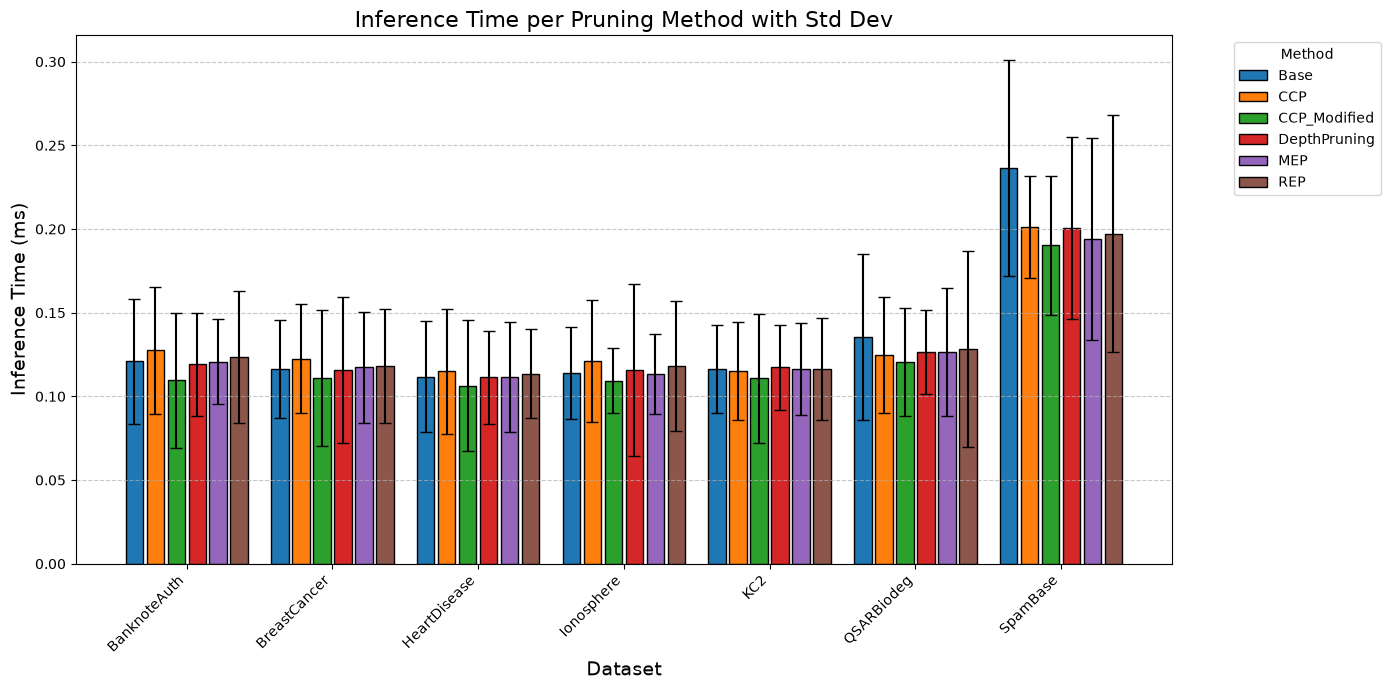

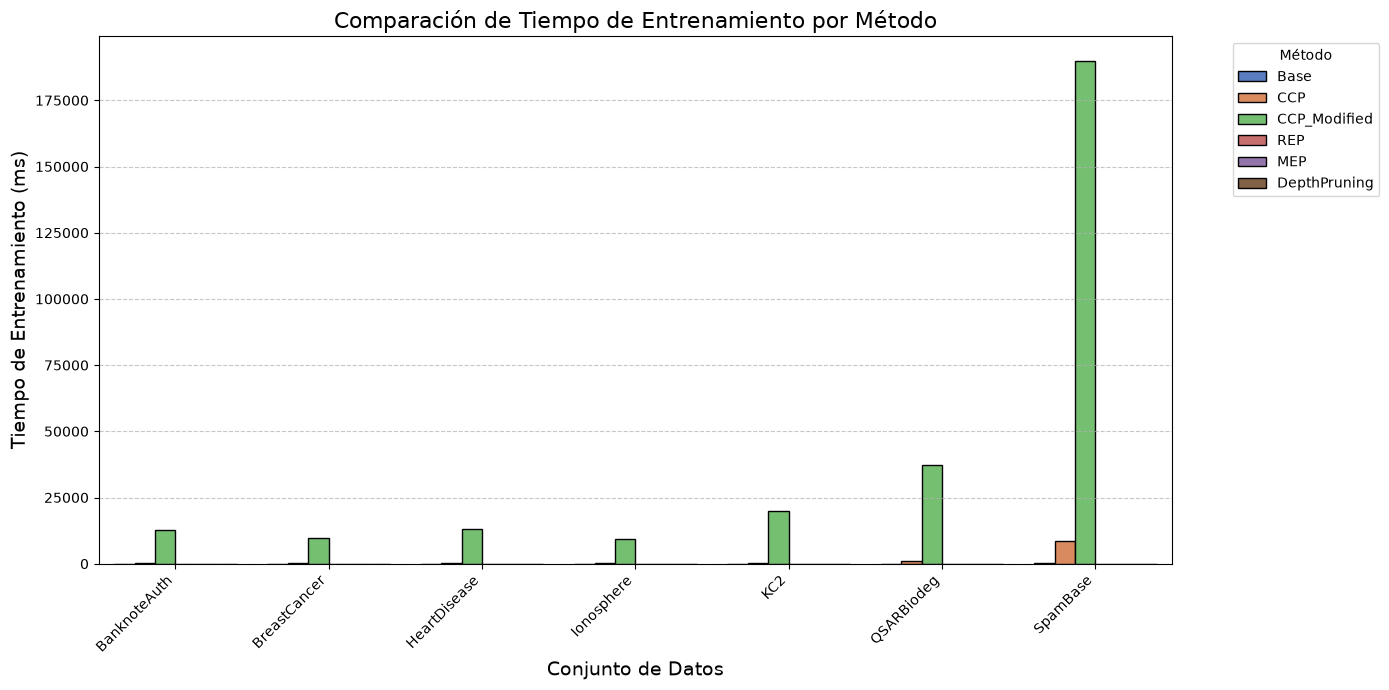

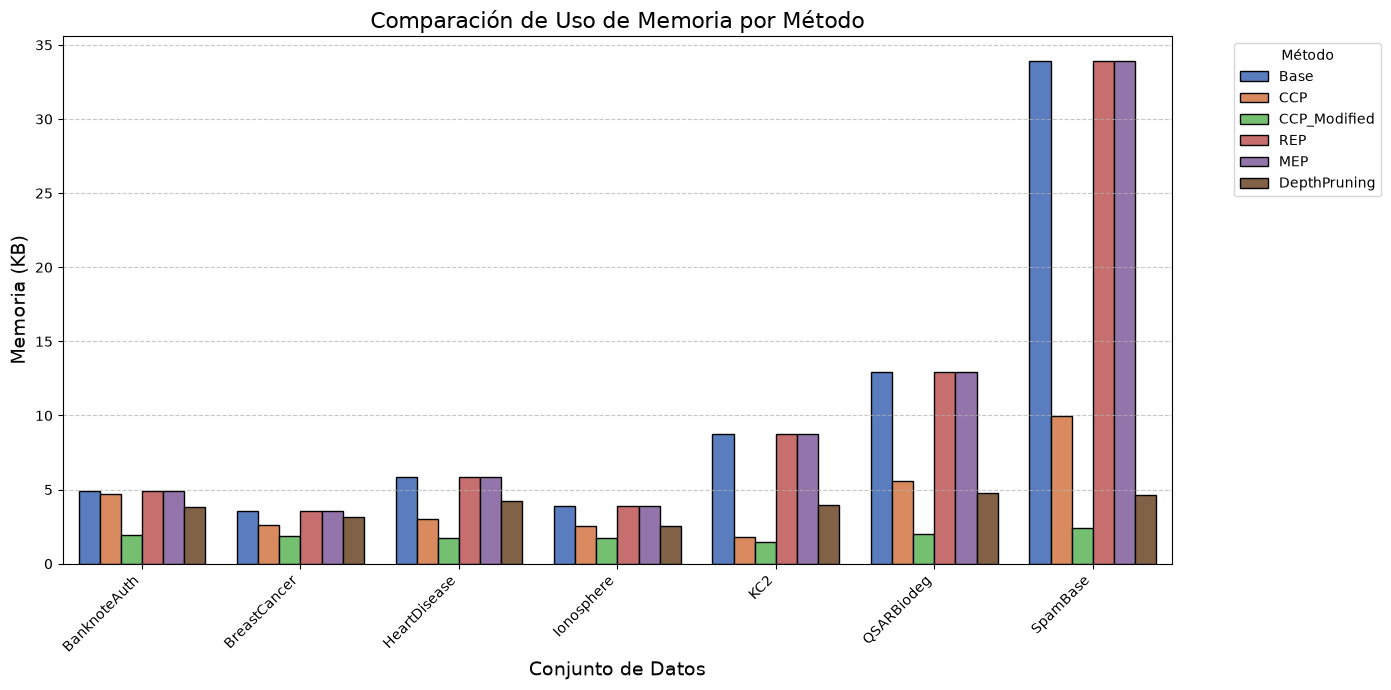

In [11]:
# Gráfica de barras para F1 Score
plt.figure(figsize=(14, 7))
ax = sns.barplot(data=metrics_df, x="Dataset", y="F1_Score", hue="Method", palette="muted", edgecolor="black")
plt.title("Comparación de F1 Score por Método de Poda", fontsize=16)
plt.ylabel("F1 Score", fontsize=14)
plt.xlabel("Conjunto de Datos", fontsize=14)
plt.xticks(rotation=45, ha="right")
plt.ylim(0, 1)
plt.grid(axis="y", linestyle='--', alpha=0.7)
plt.legend(title="Método", bbox_to_anchor=(1.05, 1), loc='upper left')
annotate_bars(ax, fmt="{:.2f}")
plt.tight_layout()
plt.show()

# Gráfica de barras para Balanced Accuracy
plt.figure(figsize=(14, 7))
ax = sns.barplot(data=metrics_df, x="Dataset", y="Balanced_Accuracy", hue="Method", palette="muted", edgecolor="black")
plt.title("Comparación de Balanced Accuracy por Método de Poda", fontsize=16)
plt.ylabel("Balanced Accuracy", fontsize=14)
plt.xlabel("Conjunto de Datos", fontsize=14)
plt.xticks(rotation=45, ha="right")
plt.ylim(0, 1)
plt.grid(axis="y", linestyle='--', alpha=0.7)
plt.legend(title="Método", bbox_to_anchor=(1.05, 1), loc='upper left')
annotate_bars(ax, fmt="{:.2f}")
plt.tight_layout()
plt.show()




# Compute average and std per group
grouped = metrics_df.groupby(["Dataset", "Method"], as_index=False).mean()

# Create the bar plot with error bars
plt.figure(figsize=(14, 7))

# Get unique methods and datasets
methods = grouped["Method"].unique()
datasets = grouped["Dataset"].unique()

# Create position indices for grouped bars
x = np.arange(len(datasets))
width = 0.12  # width of each bar
offsets = np.linspace(-width*len(methods)/2, width*len(methods)/2, len(methods))

for i, method in enumerate(methods):
    subset = grouped[grouped["Method"] == method]
    y = subset["Inference_Time_ms"].values
    yerr = subset["Inference_Time_Std_ms"].values
    plt.bar(x + offsets[i], y, width, label=method, yerr=yerr, capsize=4, edgecolor="black")

plt.xticks(x, datasets, rotation=45, ha="right")
plt.title("Inference Time per Pruning Method with Std Dev", fontsize=16)
plt.xlabel("Dataset", fontsize=14)
plt.ylabel("Inference Time (ms)", fontsize=14)
plt.grid(axis="y", linestyle='--', alpha=0.7)
plt.ylim(bottom=0)
plt.legend(title="Method", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# === Gráfica: Tiempo de Entrenamiento ===
plt.figure(figsize=(14, 7))
ax = sns.barplot(data=metrics_df, x="Dataset", y="Train_Time_ms", hue="Method", palette="muted", edgecolor="black")
plt.title("Comparación de Tiempo de Entrenamiento por Método", fontsize=16)
plt.ylabel("Tiempo de Entrenamiento (ms)", fontsize=14)
plt.xlabel("Conjunto de Datos", fontsize=14)
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", linestyle='--', alpha=0.7)
plt.legend(title="Método", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# === Gráfica: Uso de Memoria ===
plt.figure(figsize=(14, 7))
ax = sns.barplot(data=metrics_df, x="Dataset", y="Memory_KB", hue="Method", palette="muted", edgecolor="black")
plt.title("Comparación de Uso de Memoria por Método", fontsize=16)
plt.ylabel("Memoria (KB)", fontsize=14)
plt.xlabel("Conjunto de Datos", fontsize=14)
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", linestyle='--', alpha=0.7)
plt.legend(title="Método", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


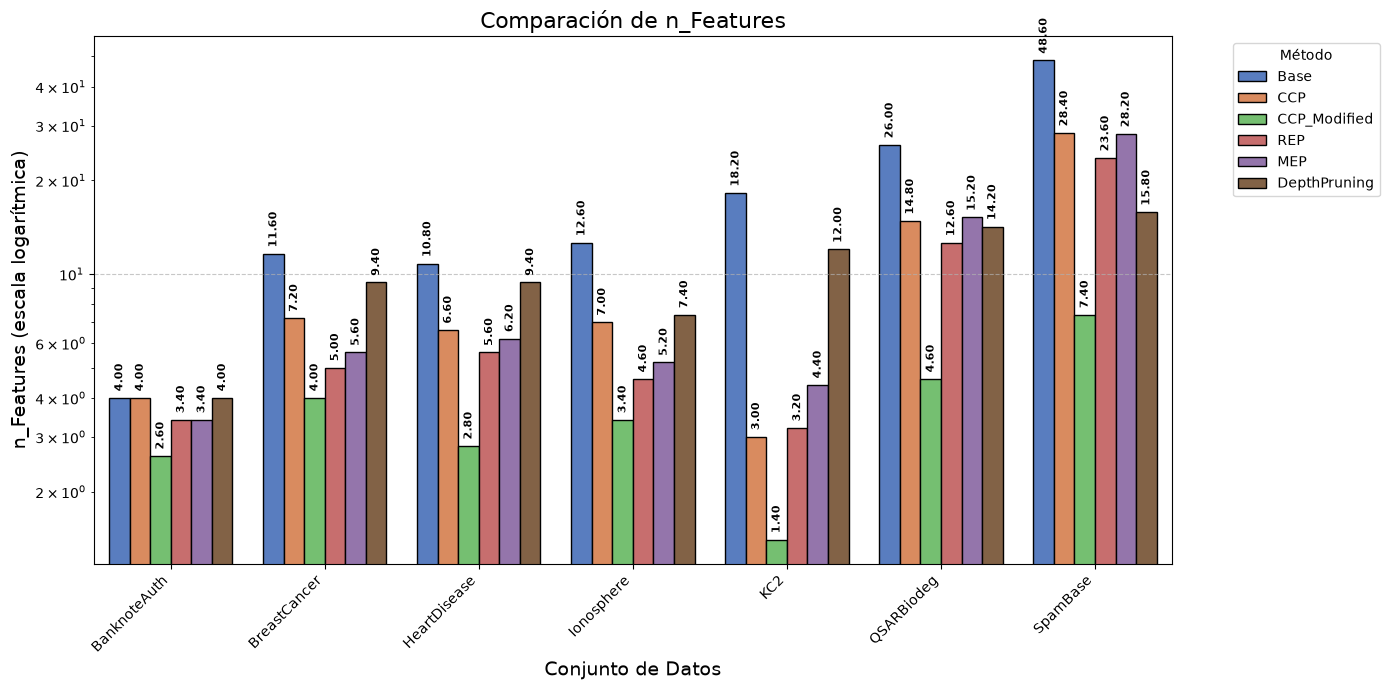

In [12]:
# === Gráfica 5: n_Features ===
plt.figure(figsize=(14, 7))
ax = sns.barplot(data=metrics_df, x="Dataset", y="n_Features", hue="Method", palette="muted", edgecolor="black")
plt.yscale('log')
plt.title("Comparación de n_Features", fontsize=16)
plt.ylabel("n_Features (escala logarítmica)", fontsize=14)
plt.xlabel("Conjunto de Datos", fontsize=14)
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", linestyle='--', alpha=0.7)
plt.legend(title="Método", bbox_to_anchor=(1.05, 1), loc='upper left')
annotate_bars(ax, fmt="{:.2f}")
plt.tight_layout()
plt.show()